# Echo Chamber Ratio 2.0 (ECR 2.0) - Full Analysis Pipeline

**Unified notebook** yang menggabungkan seluruh pipeline:
1. **Preprocessing** - Load, clean, dan prepare data dari CSV IndSight
2. **Sentiment -> Probability** - Konversi label sentimen ke distribusi probabilitas
3. **Kalibrasi** - Probability calibration (Isotonic Regression per-class)
4. **Graph Building** - Bangun graf interaksi (reply, retweet, mention)
5. **User Leaning** - Estimasi kecenderungan user berdasarkan probabilitas terkalibrasi
6. **Community Detection** - Deteksi komunitas (Leiden / Louvain)
7. **ECR 2.0 Computation** - Hitung Echo Chamber Ratio (intra/inter agreement)
8. **Diffusion Bias (IC)** - Simulasi Independent Cascade
9. **Community Analysis** - Pro vs Contra, central users, bridge users, topic shifts
10. **Visualisasi** - Grafik komprehensif dari seluruh hasil analisis

---
**Dependencies:** `pandas numpy networkx igraph leidenalg scikit-learn matplotlib seaborn tqdm emoji`

## 0. Setup & Imports

In [85]:
from __future__ import annotations

import math
import random
import copy
import re
import warnings
from dataclasses import dataclass
from typing import Any, Dict, Iterable, List, Optional, Tuple
from collections import defaultdict, Counter
from itertools import combinations

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# sklearn
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, brier_score_loss)

# scipy
from scipy.optimize import minimize_scalar
from scipy import stats as scipy_stats

try:
    import igraph as ig
    import leidenalg as la
    _HAS_LEIDEN = True
except ImportError:
    _HAS_LEIDEN = False

try:
    from infomap import Infomap
    _HAS_INFOMAP = True
except ImportError:
    _HAS_INFOMAP = False

try:
    import emoji
    _HAS_EMOJI = True
except ImportError:
    _HAS_EMOJI = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("LIBRARY STATUS")
print(f"  Leiden    : {_HAS_LEIDEN}")
print(f"  Infomap   : {_HAS_INFOMAP}")
print(f"  emoji     : {_HAS_EMOJI}")
print(f"  scipy     : True")
print(f"  sklearn   : True")

LIBRARY STATUS
  Leiden    : True
  Infomap   : True
  emoji     : True
  scipy     : True
  sklearn   : True


---
## 1. Preprocessing

Load data dari file CSV yang sudah dibersihkan (hapus URL, mention, hashtag, emoji), 
hapus duplikat, dan pilih kolom yang relevan.

In [86]:
# 1a. Load data + helper functions

# Helper functions
def normalize_id(uid):
    """Normalisasi user ID ke integer string yang konsisten.
    '1.342e+18' -> '1342808971912998912', '2754745839.0' -> '2754745839'"""
    if pd.isna(uid): return None
    uid = str(uid).strip()
    if not uid or uid in ('nan', 'None', ''): return None
    try: return str(int(float(uid)))
    except (ValueError, OverflowError): return uid

def parse_mentioned(raw):
    # Parse kolom mentioned: (name,USERNAME)//(id,USERID) pairs.
    if not raw or str(raw) == 'nan': return []
    pattern = r'\(name,([^)]+)\)//\(id,([^)]+)\)'
    return [{'username': m[0].strip(), 'user_id': normalize_id(m[1].strip())}
            for m in re.findall(pattern, str(raw)) if normalize_id(m[1].strip())]

# Baca data
data = pd.read_csv("gpt54_sentiment_results.csv", low_memory=False)
print(f"Shape: {data.shape}")
data['from_id'] = data['from_id'].apply(normalize_id)

# Build username_map dari SEMUA sumber
username_map = {}

# Sumber 1: from_username 
_u = data[['from_id','from_username']].dropna(subset=['from_username']).drop_duplicates('from_id')
username_map.update(dict(zip(_u['from_id'], _u['from_username'])))
print(f"Username dari data utama: {len(username_map):,}")

# Sumber 2: kolom mentioned -> (name,USERNAME)//(id,USERID)
n_added = 0
for raw in data['mentioned'].dropna():
    for item in parse_mentioned(raw):
        if item['user_id'] and item['user_id'] not in username_map:
            username_map[item['user_id']] = item['username']
            n_added += 1
print(f"Username dari mentioned: +{n_added:,} baru (total: {len(username_map):,})")

print(f"\nTotal username_map: {len(username_map):,}")
for uid, uname in list(username_map.items())[:5]:
    print(f"{uid} -> {uname}")

data.head()

Shape: (10000, 19)
Username dari data utama: 8,654
Username dari mentioned: +1,394 baru (total: 10,048)

Total username_map: 10,048
1206518264811020288 -> Mythicalforest
2937126368 -> thewirjos
1129936609 -> RRIPrograma3
53347814 -> eristadona
1192662731167371264 -> JuseyoiKON


,original_id,from_id,from_username,cleaned_text,final_sentiment,sentiment_confidence_level,reply_to_user_id,retweet_from_user_id,mentioned,p_neg,p_neu,p_pos,p_neg_cal,p_neu_cal,p_pos_cal,calibrated_sentiment,calibrated_confidence,sentiment_changed,gpt_label
0,1420723526231678993,1206518264811020288,Mythicalforest,Keadaan memang benar-benar begitu cepat beruba...,positive,0.775470,NaN,NaN,NaN,0.074843,0.074843,0.850313,1.000000e-12,1.000000e-12,1.000000e+00,positive,1.0,False,negative
1,1411716155702595584,2937126368,thewirjos,"Klw dada seharian nyesek, parno sendiri antara...",positive,0.562764,9.786466e+08,NaN,"(id,978646566)//(name,afrkml)",0.145745,0.145745,0.708509,1.000000e-12,1.000000e-12,1.000000e+00,positive,1.0,False,negative
2,1417484438372425728,1129936609,RRIPrograma3,Kabareskrim: Tindak Tegas Hoaks Penanganan Cov...,positive,0.572234,NaN,NaN,"(id,2432833154)//(name,RRI)",0.142589,0.142589,0.714823,1.000000e-12,1.000000e-12,1.000000e+00,positive,1.0,False,neutral
3,1421168660513624066,53347814,eristadona,"Penutupan jalan itu bener2 useless, bikin maki...",positive,0.649498,NaN,NaN,NaN,0.116834,0.116834,0.766332,1.000000e-12,1.000000e-12,1.000000e+00,positive,1.0,False,negative
4,1416404423530618886,1192662731167371264,JuseyoiKON,Covid gini w mikir punya pacar aja ngga nder :((,negative,0.498327,1.197225e+18,NaN,"(id,1197225394866282496)//(name,Askrlfess)",0.665551,0.167224,0.167224,1.000000e+00,1.000000e-12,1.000000e-12,negative,1.0,False,negative


In [87]:
def get_username(user_id):
    # Lookup username. Return @ID jika tidak ditemukan.
    nid = normalize_id(user_id)
    uname = username_map.get(nid)
    return uname if uname else (f"@{nid}" if nid else f"@{user_id}")

# 1d. Pilih kolom & normalize semua ID
REQUIRED_COLS = [
    'original_id', 'from_id', 'from_username', 'cleaned_text',
    'gpt_label', 'reply_to_user_id', 'retweet_from_user_id', 'mentioned', 
]
available = [c for c in REQUIRED_COLS if c in data.columns]
df = data[available].copy()
df = df.dropna(subset=['cleaned_text'])
df = df[df['cleaned_text'].str.strip() != '']

print(f"After language filter (Indonesian only): {df.shape}")

# Normalize SEMUA kolom ID agar konsisten
for id_col in ['from_id', 'reply_to_user_id', 'retweet_from_user_id']:
    if id_col in df.columns:
        df[id_col] = df[id_col].apply(normalize_id)

# Hard-coded sentiment probabilities from gpt_label (one-hot)
if 'gpt_label' not in df.columns:
    raise KeyError("Kolom 'gpt_label' tidak ditemukan. Tidak bisa membentuk p_neg/p_neu/p_pos.")

label_norm = df['gpt_label'].astype(str).str.strip().str.lower()
label_to_onehot = {
    'negative': (1.0, 0.0, 0.0),
    'neutral':  (0.0, 1.0, 0.0),
    'positive': (0.0, 0.0, 1.0),
    'negatif':  (1.0, 0.0, 0.0),
    'netral':   (0.0, 1.0, 0.0),
    'positif':  (0.0, 0.0, 1.0),
}
onehot = label_norm.map(label_to_onehot)

if onehot.isna().any():
    unknown = sorted(label_norm[onehot.isna()].unique().tolist())
    raise ValueError(f"Nilai gpt_label tidak dikenali: {unknown[:10]}")

df[['p_neg', 'p_neu', 'p_pos']] = pd.DataFrame(onehot.tolist(), index=df.index)

print("[OK] p_neg/p_neu/p_pos dibuat dari gpt_label (hard-coded one-hot)")
print(df[['gpt_label', 'p_neg', 'p_neu', 'p_pos']].head())

# Test username lookup
print("Username lookup test:")
for sid in df['from_id'].dropna().unique()[:5]:
    print(f"{sid} -> {get_username(sid)}")
    
print(f"\nFinal shape: {df.shape}")

After language filter (Indonesian only): (10000, 8)
[OK] p_neg/p_neu/p_pos dibuat dari gpt_label (hard-coded one-hot)
  gpt_label  p_neg  p_neu  p_pos
0  negative    1.0    0.0    0.0
1  negative    1.0    0.0    0.0
2   neutral    0.0    1.0    0.0
3  negative    1.0    0.0    0.0
4  negative    1.0    0.0    0.0
Username lookup test:
1206518264811020288 -> Mythicalforest
2937126368 -> thewirjos
1129936609 -> RRIPrograma3
53347814 -> eristadona
1192662731167371264 -> JuseyoiKON

Final shape: (10000, 11)


---
## 4. Build Interaction Graph
1. **Mention parsing**  --  bersihkan karakter sampah (tanda kurung, spasi, non-alphanumeric trailing chars)
2. **Filter edges**  --  hanya simpan edges di mana **kedua** user punya data content/leaning
3. Ini memastikan tidak ada node "ghost" yang menyebabkan NaN

In [88]:
# 4a. Build graph function

def build_graph(
    interactions: pd.DataFrame,
    directed: bool = True,
) -> Tuple:
    G = nx.DiGraph() if directed else nx.Graph()
    
    for _, row in tqdm(interactions.iterrows(), total=len(interactions), desc="Building graph", leave=False):
        s, d = str(row["src"]).strip(), str(row["dst"]).strip()
        w = float(row.get("weight", 1.0))
        t = row.get("type", "edge")
        if G.has_edge(s, d):
            G[s][d]["weight"] += w
        else:
            G.add_edge(s, d, weight=w, itype=t)
    
    df_nodes = pd.DataFrame({"user": list(G.nodes())})
    return G, df_nodes

In [89]:
# 4b. Prepare interactions -- proper mention parsing
content_users = set(df['from_id'].dropna().unique())
print(f"Users with content: {len(content_users):,}")
interactions_list = []

# Reply
if 'reply_to_user_id' in df.columns:
    r = df.loc[df['reply_to_user_id'].notna(), ['from_id','reply_to_user_id']].copy()
    r.columns = ['src','dst']; r = r.dropna(); r['type']='reply'; r['weight']=1
    interactions_list.append(r); print(f"Reply: {len(r):,}")

# Retweet
rt_col = 'retweet_from_user_id'
if rt_col in df.columns:
    r = df.loc[df[rt_col].notna(), ['from_id', rt_col]].copy()
    r.columns = ['src','dst']; r = r.dropna(); r['type']='retweet'; r['weight']=1
    interactions_list.append(r); print(f"Retweet: {len(r):,}")

# Mention, parse (name,XXX)//(id,YYY) format
if 'mentioned' in df.columns:
    md = []
    for _, row in df[df['mentioned'].notna()].iterrows():
        for item in parse_mentioned(row['mentioned']):
            if item['user_id'] and item['user_id'] != row['from_id']:
                md.append({'src': row['from_id'], 'dst': item['user_id'],
                           'type': 'mention', 'weight': 1})
    if md:
        interactions_list.append(pd.DataFrame(md)); print(f"Mention: {len(md):,}")

interactions = pd.concat(interactions_list, ignore_index=True)
interactions = interactions[interactions['src'] != interactions['dst']]
before = len(interactions)
interactions = interactions[interactions['src'].isin(content_users) & interactions['dst'].isin(content_users)]
print(f"\nFiltered: {before:,} -> {len(interactions):,}")
print(f"\n{interactions['type'].value_counts()}")

Users with content: 8,654
Reply: 3,883
Retweet: 0
Mention: 2,425

Filtered: 5,771 -> 940

type
reply      539
mention    401
Name: count, dtype: int64


In [90]:
# 4c. Build the graph

G, df_nodes = build_graph(interactions, directed=True)

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)

print(f"\nGraph Statistics:")
print(f"Nodes: {n_nodes:,}")
print(f"Edges: {n_edges:,}")
print(f"Density: {density:.6f}")
print(f"Avg degree: {2*n_edges/n_nodes:.2f}")

# Verifikasi: semua node punya content data
nodes_without_content = set(G.nodes()) - content_users
print(f"\nNodes without content: {len(nodes_without_content)} (harus 0)")


Graph Statistics:
Nodes: 1,066
Edges: 909
Density: 0.000801
Avg degree: 1.71

Nodes without content: 0 (harus 0)


---
## 5. Estimasi User Leaning

Menghitung kecenderungan setiap user dalam skala [-1, +1] menggunakan probabilitas **terkalibrasi**.

**Mapping Pro/Kontra untuk topik "Vaksinasi":**
- **Sentimen POSITIF** = **PRO** topik (setuju Vaksinasi) -> lean_scalar positif (+1)
- **Sentimen NEGATIF** = **KONTRA** topik (tidak setuju Vaksinasi) -> lean_scalar negatif (-1)
- **Sentimen NETRAL** = Netral -> lean_scalar sekitar 0

Parameter `topic_polarity="positive_is_pro"` mengontrol mapping ini.
Untuk topik lain dimana sentimen negatif = PRO, gunakan `"negative_is_pro"`.

In [91]:
def estimate_user_leaning(
    content: pd.DataFrame,
    user_col: str = "user",
    proba_cols: Tuple[str, ...] = ("p_neg", "p_neu", "p_pos"),
    topic_polarity: str = "positive_is_pro",
) -> pd.DataFrame:
    """Estimate per-user scalar leaning in [-1, +1].

    topic_polarity:
        'positive_is_pro': sentimen positif = PRO topik -> lean = -1*p_neg + 0*p_neu + +1*p_pos
        'negative_is_pro': sentimen negatif = PRO topik -> lean = +1*p_neg + 0*p_neu + -1*p_pos
    """
    df_c = content.copy()

    p_neg, p_neu, p_pos = [df_c[c].astype(float).values for c in proba_cols]
    eps = 1e-12
    s = p_neg + p_neu + p_pos + eps
    p_neg, p_neu, p_pos = p_neg/s, p_neu/s, p_pos/s

    if topic_polarity == "negative_is_pro":
        df_c["lean_scalar"] = 1.0 * p_neg + 0.0 * p_neu + (-1.0) * p_pos
    else:
        df_c["lean_scalar"] = (-1.0) * p_neg + 0.0 * p_neu + 1.0 * p_pos

    P = np.vstack([p_neg, p_neu, p_pos]).T
    ent = -np.sum(np.where(P > 0, P * np.log(P + 1e-12), 0.0), axis=1)
    ent_max = math.log(3.0)
    df_c["conf"] = 1.0 - (ent / ent_max)
    df_c["_p_neg"] = p_neg
    df_c["_p_neu"] = p_neu
    df_c["_p_pos"] = p_pos

    agg = df_c.groupby(user_col).agg(
        lean_scalar=("lean_scalar", "mean"),
        conf=("conf", "mean"),
        p_neg_mean=("_p_neg", "mean"),
        p_neu_mean=("_p_neu", "mean"),
        p_pos_mean=("_p_pos", "mean"),
    ).reset_index()
    agg.rename(columns={user_col: "user"}, inplace=True)
    agg["lean_scalar"] = agg["lean_scalar"].clip(-1.0, 1.0)
    agg["conf"] = agg["conf"].clip(0.0, 1.0)

    return agg

# Buat content table dengan probabilitas TERKALIBRASI
content = df[['from_id', 'p_neg', 'p_neu', 'p_pos']].copy()
content.columns = ['user', 'p_neg', 'p_neu', 'p_pos']

df_users = estimate_user_leaning(content, user_col='user',
                                  proba_cols=('p_neg', 'p_neu', 'p_pos'),
                                  topic_polarity='positive_is_pro')

print(f"Users with leaning (from content): {len(df_users):,}")
print(f"Columns: {list(df_users.columns)}")

# Propagate leaning ke node graf yang TIDAK punya content
graph_nodes = set(G.nodes())
users_with_lean = set(df_users['user'].values)
nodes_without_lean = graph_nodes - users_with_lean

print(f"Graph nodes without content: {len(nodes_without_lean):,}")

if len(nodes_without_lean) > 0:
    lean_dict = dict(zip(df_users['user'], df_users['lean_scalar']))
    conf_dict = dict(zip(df_users['user'], df_users['conf']))
    pn_dict = dict(zip(df_users['user'], df_users['p_neg_mean']))
    pneu_dict = dict(zip(df_users['user'], df_users['p_neu_mean']))
    pp_dict = dict(zip(df_users['user'], df_users['p_pos_mean']))

    propagated = []
    for node in nodes_without_lean:
        nbrs = list(G.predecessors(node)) + list(G.successors(node)) if isinstance(G, nx.DiGraph) else list(G.neighbors(node))
        neighbor_leans = [lean_dict[n] for n in nbrs if n in lean_dict]

        if neighbor_leans:
            propagated.append({
                'user': node,
                'lean_scalar': float(np.mean(neighbor_leans)),
                'conf': 0.5,
                'p_neg_mean': float(np.mean([pn_dict.get(n, 0.33) for n in nbrs if n in pn_dict])),
                'p_neu_mean': float(np.mean([pneu_dict.get(n, 0.33) for n in nbrs if n in pneu_dict])),
                'p_pos_mean': float(np.mean([pp_dict.get(n, 0.33) for n in nbrs if n in pp_dict])),
            })

    if propagated:
        df_propagated = pd.DataFrame(propagated)
        df_users = pd.concat([df_users, df_propagated], ignore_index=True)
        print(f"Propagated leaning to {len(propagated):,} nodes from neighbors")

print(f"\nTotal users with leaning: {len(df_users):,}")
print(f"\nLeaning statistics:")
print(df_users[['lean_scalar', 'conf']].describe())

# Verifikasi coverage
users_with_lean = set(df_users['user'].values)
coverage = len(graph_nodes & users_with_lean)
print(f"\n[OK] Graph nodes with leaning: {coverage:,} / {len(graph_nodes):,} ({100*coverage/len(graph_nodes):.1f}%)")

# Validasi: assert 1:1 user mapping
assert df_users['user'].duplicated().sum() == 0, "DUPLICATE users detected!"
print("[OK] 1:1 user mapping verified (no duplicates)")

Users with leaning (from content): 8,654
Columns: ['user', 'lean_scalar', 'conf', 'p_neg_mean', 'p_neu_mean', 'p_pos_mean']
Graph nodes without content: 0

Total users with leaning: 8,654

Leaning statistics:
       lean_scalar          conf
count  8654.000000  8.654000e+03
mean     -0.353418  1.000000e+00
std       0.731562  1.114129e-16
min      -1.000000  1.000000e+00
25%      -1.000000  1.000000e+00
50%      -1.000000  1.000000e+00
75%       0.000000  1.000000e+00
max       1.000000  1.000000e+00

[OK] Graph nodes with leaning: 1,066 / 1,066 (100.0%)
[OK] 1:1 user mapping verified (no duplicates)


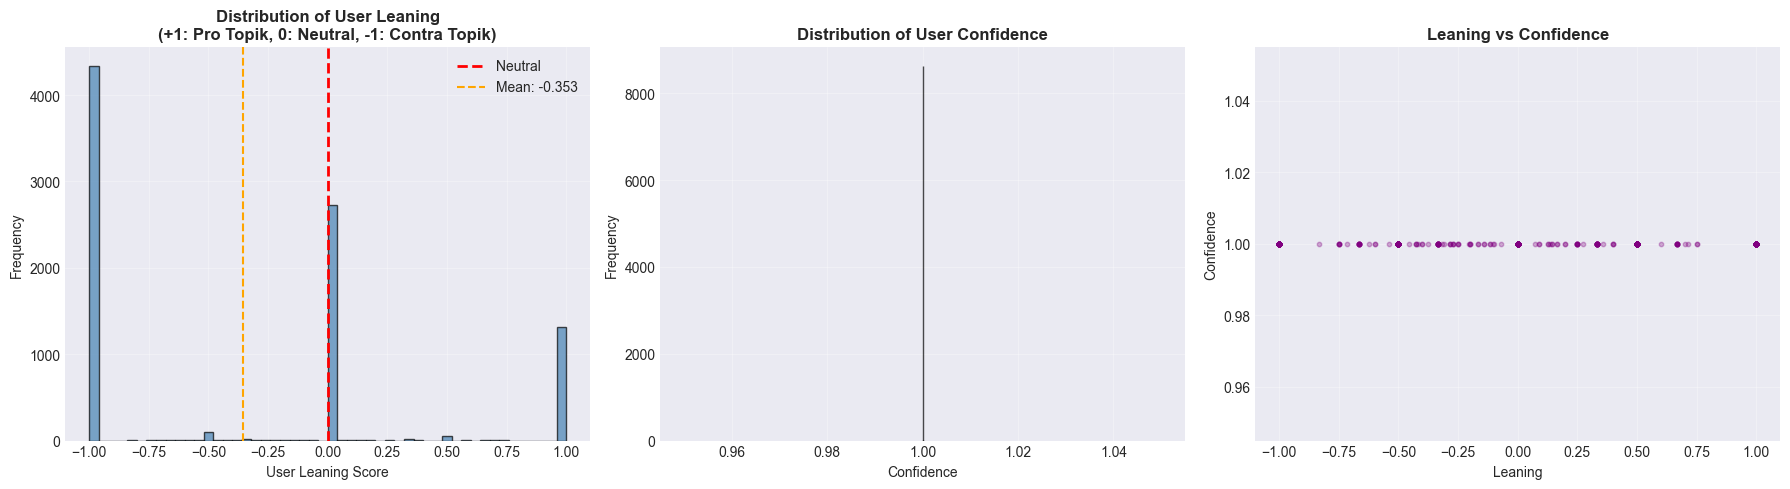

In [117]:
# Visualisasi user leaning
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_users['lean_scalar'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Neutral')
axes[0].axvline(x=df_users['lean_scalar'].mean(), color='orange', linestyle='--',
                label=f'Mean: {df_users["lean_scalar"].mean():.3f}')
axes[0].set_xlabel('User Leaning Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of User Leaning\n(+1: Pro Topik, 0: Neutral, -1: Contra Topik)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_users['conf'], bins=2, edgecolor='black', alpha=0.7, color='teal')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of User Confidence', fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(df_users['lean_scalar'], df_users['conf'], alpha=0.3, s=10, c='purple')
axes[2].set_xlabel('Leaning')
axes[2].set_ylabel('Confidence')
axes[2].set_title('Leaning vs Confidence', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_user_leaning.png', dpi=150, bbox_inches='tight')
plt.show()

=== USER STATS DIAGNOSTICS ===

Distribusi jumlah posts per user:
count    8654.000000
mean        1.155535
std         1.070855
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        40.000000
Name: n_posts, dtype: float64

Dominant sentiment distribution:
dominant_sentiment
negative    4532
neutral     2785
positive    1337
Name: count, dtype: int64


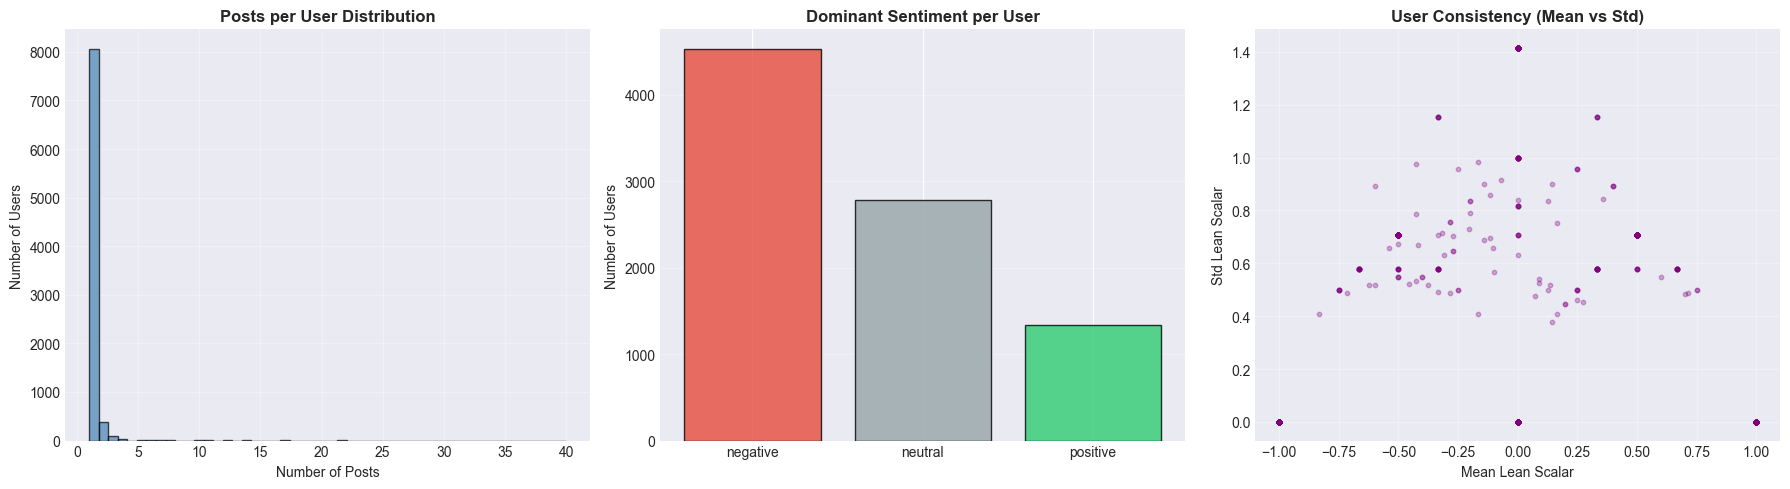

In [93]:
# 5b. User Stats Diagnostics (aggregate_user_stats)

def aggregate_user_stats(content_df, user_col='user', proba_cols=('p_neg', 'p_neu', 'p_pos')):
    """Diagnostic per-user statistics."""
    df_c = content_df.copy()
    p_neg, p_neu, p_pos = [df_c[c].astype(float).values for c in proba_cols]
    eps = 1e-12
    s = p_neg + p_neu + p_pos + eps
    p_neg, p_neu, p_pos = p_neg/s, p_neu/s, p_pos/s
    # Konteks vaksin: POSITIF = PRO (+), NEGATIF = KONTRA (-)
    df_c["lean_scalar"] = (-1.0)*p_neg + 0.0*p_neu + (1.0)*p_pos
    df_c["_p_neg"], df_c["_p_neu"], df_c["_p_pos"] = p_neg, p_neu, p_pos
    labels = np.array(['negative', 'neutral', 'positive'])
    P = np.vstack([p_neg, p_neu, p_pos]).T
    df_c["_dominant"] = labels[np.argmax(P, axis=1)]

    agg = df_c.groupby(user_col).agg(
        n_posts=(user_col, 'count'),
        lean_scalar=('lean_scalar', 'mean'),
        lean_std=('lean_scalar', 'std'),
        p_neg_mean=('_p_neg', 'mean'),
        p_neu_mean=('_p_neu', 'mean'),
        p_pos_mean=('_p_pos', 'mean'),
        dominant_sentiment=('_dominant', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'neutral'),
    ).reset_index()
    agg['lean_std'] = agg['lean_std'].fillna(0)
    return agg

user_stats = aggregate_user_stats(content, user_col='user')

print("=== USER STATS DIAGNOSTICS ===")
print(f"\nDistribusi jumlah posts per user:")
print(user_stats['n_posts'].describe())

print(f"\nDominant sentiment distribution:")
print(user_stats['dominant_sentiment'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(user_stats['n_posts'].clip(0, 100), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Number of Posts')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Posts per User Distribution', fontweight='bold')
axes[0].grid(True, alpha=0.3)

dom_counts = user_stats['dominant_sentiment'].value_counts()
colors_dom = {'negative': '#e74c3c', 'neutral': '#95a5a6', 'positive': '#2ecc71'}
axes[1].bar(dom_counts.index, dom_counts.values,
            color=[colors_dom.get(s, 'gray') for s in dom_counts.index], alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('Dominant Sentiment per User', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].scatter(user_stats['lean_scalar'], user_stats['lean_std'], alpha=0.3, s=10, c='purple')
axes[2].set_xlabel('Mean Lean Scalar')
axes[2].set_ylabel('Std Lean Scalar')
axes[2].set_title('User Consistency (Mean vs Std)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Community Detection

Using resolution: 3.028
Communities detected: 208

Top 10 community sizes:
0    51
1    41
2    37
3    33
4    28
5    27
8    26
7    26
6    26
9    24
Name: count, dtype: int64


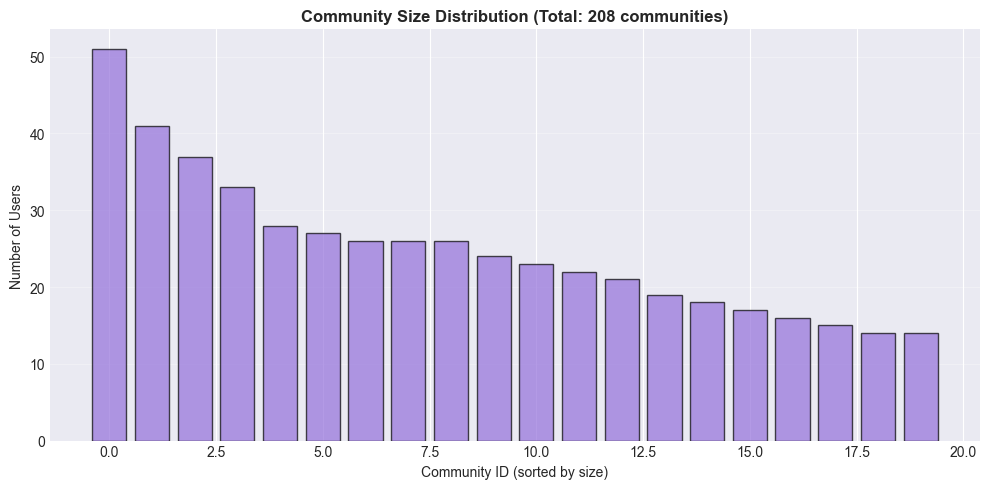

In [94]:
def detect_communities(
    G, method: str = "leiden", resolution: float = 1.0, random_state: int = 42
) -> Dict[str, int]:
    if method == "leiden" and _HAS_LEIDEN:
        mapping = {n: i for i, n in enumerate(G.nodes())}
        inv = {i: n for n, i in mapping.items()}
        edges = [(mapping[u], mapping[v]) for u, v in G.edges()]
        ig_g = ig.Graph(n=len(G), edges=edges, directed=isinstance(G, nx.DiGraph))
        if isinstance(G, nx.DiGraph):
            ig_g.to_undirected(mode="collapse")
        partition = la.find_partition(
            ig_g, la.RBConfigurationVertexPartition,
            resolution_parameter=resolution, seed=random_state
        )
        return {inv[i]: partition.membership[i] for i in range(len(G))}
    else:
        print(f"WARNING: Leiden method not available. Falling back to Louvain (undirected).")
        G_und = G.to_undirected() if isinstance(G, nx.DiGraph) else G
        try:
            partition = nx.community.louvain_communities(G_und, seed=random_state, resolution=resolution)
            result = {}
            for cid, nodes in enumerate(partition):
                for node in nodes:
                    result[node] = cid
            return result
        except:
            return {n: 0 for n in G.nodes()}

resolution = max(0.5, np.log10(n_nodes + 1))
print(f"Using resolution: {resolution:.3f}")

communities = detect_communities(G, method='leiden', resolution=resolution, random_state=42)

n_communities = len(set(communities.values()))
comm_sizes = pd.Series(communities.values()).value_counts().sort_values(ascending=False)

print(f"Communities detected: {n_communities}")
print(f"\nTop 10 community sizes:")
print(comm_sizes.head(10))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(min(20, len(comm_sizes))), comm_sizes.values[:20], color='mediumpurple', edgecolor='black', alpha=0.7)
ax.set_xlabel('Community ID (sorted by size)')
ax.set_ylabel('Number of Users')
ax.set_title(f'Community Size Distribution (Total: {n_communities} communities)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('03_community_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Homophily & ECR 2.0 Computation

**ECR 2.0 = E[intra-community] / E[inter-community]**

In [95]:
def compute_homophily(G, df_users, lean_col="lean_scalar"):
    lean = dict(zip(df_users["user"], df_users[lean_col]))
    neigh_mean = {}
    
    for u in G.nodes():
        nbrs = list(G.successors(u)) + list(G.predecessors(u)) if isinstance(G, nx.DiGraph) else list(G.neighbors(u))
        vals = [lean[v] for v in nbrs if v in lean and not np.isnan(lean[v])]
        neigh_mean[u] = float(np.mean(vals)) if vals else np.nan
    
    a, b = [], []
    for u in G.nodes():
        lu = lean.get(u, np.nan)
        mv = neigh_mean.get(u, np.nan)
        if not (np.isnan(lu) or np.isnan(mv)):
            a.append(lu); b.append(mv)
    
    r = float(np.corrcoef(a, b)[0, 1]) if len(a) >= 3 else float("nan")
    return {"neighbor_mean": neigh_mean, "pearson_r": r, "n_pairs": len(a)}


@dataclass
class ECR2Result:
    intra: float
    inter: float
    ratio: float
    homophily_r: float


def compute_ecr2(G, df_users, communities, lean_col="lean_scalar",
                 sample_edges=None, random_state=42) -> ECR2Result:
    lean = dict(zip(df_users["user"], df_users[lean_col]))
    edges = list(G.edges())
    
    if sample_edges and sample_edges < len(edges):
        rng = np.random.RandomState(random_state)
        idx = rng.choice(len(edges), size=sample_edges, replace=False)
        edges = [edges[i] for i in idx]
    
    intra_vals, inter_vals = [], []
    n_skipped = 0
    
    for u, v in edges:
        lu, lv = lean.get(u, np.nan), lean.get(v, np.nan)
        if np.isnan(lu) or np.isnan(lv):
            n_skipped += 1
            continue
        
        cu, cv = communities.get(u), communities.get(v)
        agreement = 1.0 - abs(lu - lv) / 2.0
        
        if cu is not None and cv is not None and cu == cv:
            intra_vals.append(agreement)
        else:
            inter_vals.append(agreement)
    
    intra = float(np.nanmean(intra_vals)) if intra_vals else float("nan")
    inter = float(np.nanmean(inter_vals)) if inter_vals else float("nan")
    ratio = float(intra / inter) if (inter > 0 and not np.isnan(inter)) else float("nan")
    
    homo = compute_homophily(G, df_users)
    
    print(f"  Edges processed: {len(intra_vals) + len(inter_vals):,} (skipped {n_skipped:,} due to missing leaning)")
    print(f"  Intra-community edges: {len(intra_vals):,}")
    print(f"  Inter-community edges: {len(inter_vals):,}")
    
    return ECR2Result(intra=intra, inter=inter, ratio=ratio, homophily_r=homo["pearson_r"])

In [96]:
print("Computing homophily...")
homophily = compute_homophily(G, df_users)
print(f"Homophily (Pearson r): {homophily['pearson_r']:.4f}")
print(f"Pairs used: {homophily['n_pairs']:,}")

print("\nComputing ECR 2.0...")
ecr2 = compute_ecr2(G, df_users, communities)

print(f"ECR 2.0 RESULTS")
print(f"Intra-community agreement : {ecr2.intra:.4f}")
print(f"Inter-community agreement : {ecr2.inter:.4f}")
print(f"ECR Ratio                 : {ecr2.ratio:.4f}")
print(f"Homophily (Pearson r)     : {ecr2.homophily_r:.4f}")

Computing homophily...
Homophily (Pearson r): 0.1859
Pairs used: 1,066

Computing ECR 2.0...
  Edges processed: 909 (skipped 0 due to missing leaning)
  Intra-community edges: 874
  Inter-community edges: 35
ECR 2.0 RESULTS
Intra-community agreement : 0.6993
Inter-community agreement : 0.6757
ECR Ratio                 : 1.0349
Homophily (Pearson r)     : 0.1859


---
## 8. Threshold Estimation & Classification

In [97]:
def _randomize_graph_preserve_degree(G, n_swap=None, seed=42):
    """n_swap defaults to max(|E|, 5000) for thorough randomization."""
    H = copy.deepcopy(G)
    if n_swap is None:
        n_swap = max(H.number_of_edges(), 5_000)
    try:
        if isinstance(G, nx.DiGraph):
            nx.algorithms.swap.directed_edge_swap(H, nswap=n_swap, max_tries=n_swap*10, seed=seed)
        else:
            nx.algorithms.swap.double_edge_swap(H, nswap=n_swap, max_tries=n_swap*10, seed=seed)
    except nx.NetworkXAlgorithmError:
        pass
    return H

def estimate_ecr_threshold(G, df_users, communities, n_samples=100, seed=42) -> float:
    """Null model: randomize graph edges (preserving degree), compute ECR distribution.
    threshold = mean + 1*std of null distribution.
    Uses n_samples=100 for reliable null distribution and n_swap=|E| for thorough randomization.
    """
    rng = random.Random(seed)
    vals = []
    for i in tqdm(range(n_samples), desc="Null model sampling"):
        H = _randomize_graph_preserve_degree(G, seed=rng.randint(1, 10**9))
        res = compute_ecr2(H, df_users, communities)
        if not math.isnan(res.ratio) and res.ratio > 0:
            vals.append(min(2.0, res.ratio))  # cap at 2
    if len(vals) < 3:
        return 1.0
    return float(np.clip(np.mean(vals) + np.std(vals), 0.0, 2.0))

def classify_echo_chamber(ecr_ratio: float, threshold: float) -> str:
    if math.isnan(ecr_ratio):
        return "Tidak dapat ditentukan (ECR NaN)"
    if ecr_ratio > threshold:
        return "FENOMENA ECHO CHAMBER"
    else:
        return "FENOMENA NON-ECHO CHAMBER"

print("Estimating empirical threshold...")
print(f"  Graph has {G.number_of_edges():,} edges -> n_swap = {max(G.number_of_edges(), 5000):,}")
threshold = estimate_ecr_threshold(G, df_users, communities, n_samples=100, seed=42)
classification = classify_echo_chamber(ecr2.ratio, threshold)

print(f"FINAL RESULT")
print(f"ECR Ratio    : {ecr2.ratio:.4f}")
print(f"Threshold    : {threshold:.4f}")
print(f"Kesimpulan   : {classification}")

Estimating empirical threshold...
  Graph has 909 edges -> n_swap = 5,000


Null model sampling:   0%|          | 0/100 [00:00<?, ?it/s]

  Edges processed: 909 (skipped 0 due to missing leaning)
  Intra-community edges: 874
  Inter-community edges: 35
  Edges processed: 909 (skipped 0 due to missing leaning)
  Intra-community edges: 874
  Inter-community edges: 35


Null model sampling:   2%|▏         | 2/100 [00:00<00:07, 13.01it/s]

  Edges processed: 909 (skipped 0 due to missing leaning)
  Intra-community edges: 874
  Inter-community edges: 35


...

  Edges processed: 909 (skipped 0 due to missing leaning)
  Intra-community edges: 874
  Inter-community edges: 35
  Edges processed: 909 (skipped 0 due to missing leaning)
  Intra-community edges: 874
  Inter-community edges: 35
  Edges processed: 909 (skipped 0 due to missing leaning)
  Intra-community edges: 874
  Inter-community edges: 35
  Edges processed: 909 (skipped 0 due to missing leaning)
  Intra-community edges: 874
  Inter-community edges: 35


Null model sampling:  96%|█████████▌| 96/100 [00:07<00:00, 12.85it/s]

  Edges processed: 909 (skipped 0 due to missing leaning)
  Intra-community edges: 874
  Inter-community edges: 35
  Edges processed: 909 (skipped 0 due to missing leaning)
  Intra-community edges: 874
  Inter-community edges: 35
  Edges processed: 909 (skipped 0 due to missing leaning)
  Intra-community edges: 874
  Inter-community edges: 35


Null model sampling: 100%|██████████| 100/100 [00:07<00:00, 12.67it/s]

  Edges processed: 909 (skipped 0 due to missing leaning)
  Intra-community edges: 874
  Inter-community edges: 35
  Edges processed: 909 (skipped 0 due to missing leaning)
  Intra-community edges: 874
  Inter-community edges: 35
  Edges processed: 909 (skipped 0 due to missing leaning)
  Intra-community edges: 874
  Inter-community edges: 35
  Edges processed: 909 (skipped 0 due to missing leaning)
  Intra-community edges: 874
  Inter-community edges: 35
FINAL RESULT
ECR Ratio    : 1.0349
Threshold    : 1.0409
Kesimpulan   : FENOMENA NON-ECHO CHAMBER


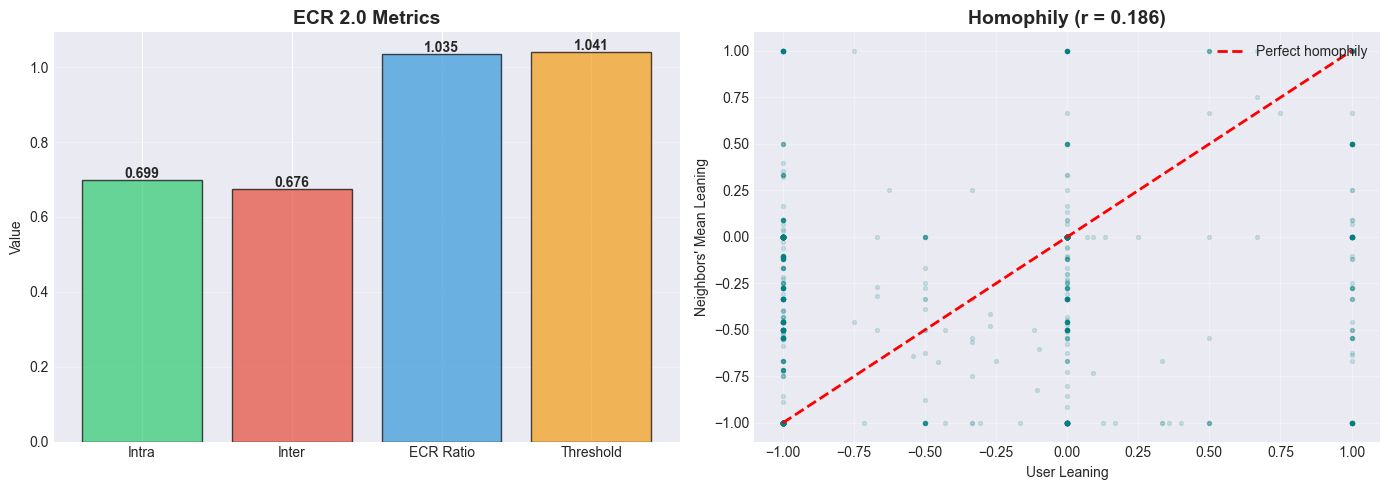

In [98]:
# Visualisasi ECR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Intra', 'Inter', 'ECR Ratio', 'Threshold']
values = [ecr2.intra, ecr2.inter, ecr2.ratio, threshold]
colors = ['#2ecc71', '#e74c3c', '#3498db' if ecr2.ratio <= threshold else '#e74c3c', '#f39c12']

bars = axes[0].bar(metrics, values, color=colors, alpha=0.7, edgecolor='black')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].set_title('ECR 2.0 Metrics', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

lean = dict(zip(df_users["user"], df_users["lean_scalar"]))
nm = homophily["neighbor_mean"]
x_v, y_v = [], []
for u in G.nodes():
    lu, mv = lean.get(u, np.nan), nm.get(u, np.nan)
    if not (np.isnan(lu) or np.isnan(mv)):
        x_v.append(lu); y_v.append(mv)
axes[1].scatter(x_v, y_v, alpha=0.15, s=8, c='teal')
axes[1].plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='Perfect homophily')
axes[1].set_xlabel('User Leaning')
axes[1].set_ylabel("Neighbors' Mean Leaning")
axes[1].set_title(f'Homophily (r = {ecr2.homophily_r:.3f})', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_ecr_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8.5 GDM Cosine Consensus (Pembanding ECR Agreement Kernel)

Membandingkan dua cara mengukur similarity antar user:
1. **Agreement kernel** (pipeline utama): `agreement(u,v) = 1 - |lean_u - lean_v| / 2`
2. **Cosine similarity** (GDM-style): `cos(proba_u, proba_v)` pada vektor probabilitas [p_neg, p_neu, p_pos]

Kedua metrik dihitung pada komunitas **Leiden yang sama** untuk melihat apakah kesimpulan ECR robust terhadap pilihan similarity measure.

=== PERBANDINGAN: Agreement Kernel vs Cosine Consensus ===

Method                 |    Intra |    Inter |  ECR Ratio
----------------------------------------------------------
Agreement kernel       |   0.6993 |   0.6757 |     1.0349
Cosine consensus       |   0.5436 |   0.5273 |     1.0309

[OK] Kedua metrik menunjukkan arah yang KONSISTEN (ECR > 1 = echo chamber signal)


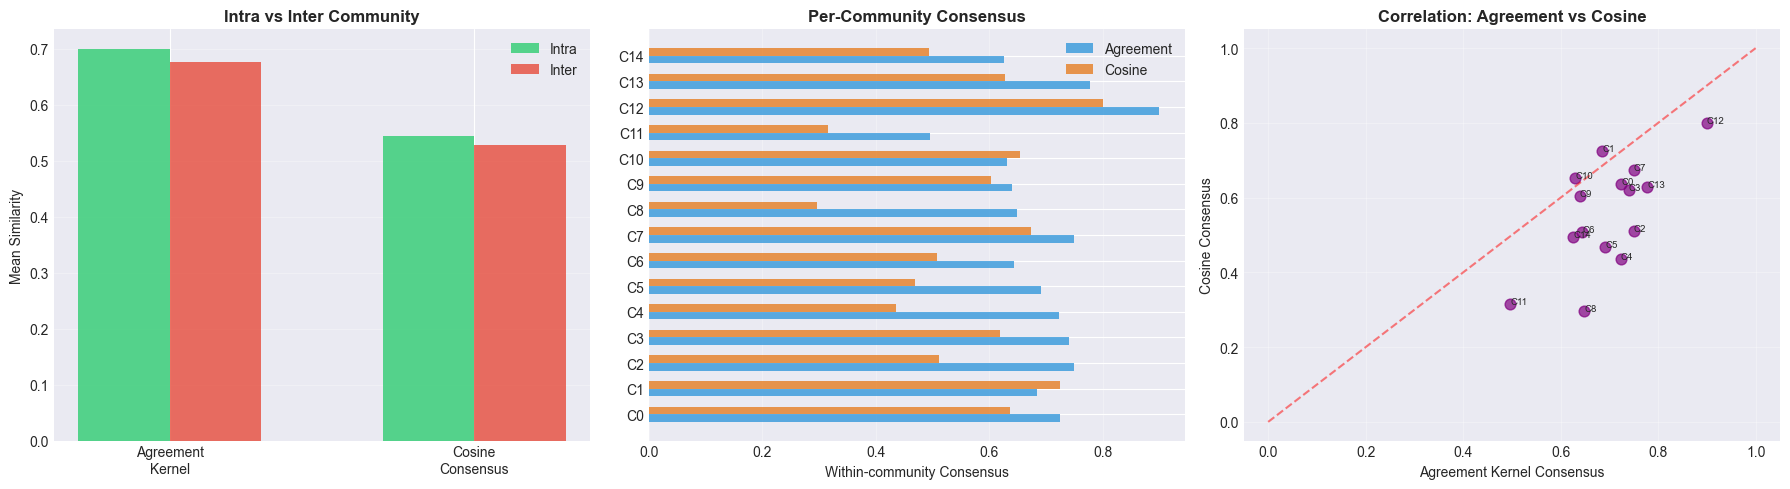

In [99]:
# 8.5a. Compute GDM Cosine Consensus

def cosine_similarity_vectors(v1, v2):
    """Cosine similarity between two probability vectors."""
    v1, v2 = np.asarray(v1, dtype=float), np.asarray(v2, dtype=float)
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 < 1e-12 or n2 < 1e-12:
        return 0.0
    return float(np.dot(v1, v2) / (n1 * n2))

# Build per-user probability vectors
user_proba = {}
for _, row in df_users.iterrows():
    uid = row['user']
    user_proba[uid] = np.array([
        row.get('p_neg_mean', 0.33),
        row.get('p_neu_mean', 0.33),
        row.get('p_pos_mean', 0.33),
    ], dtype=float)

# Per-edge cosine similarity
intra_cosine_vals, inter_cosine_vals = [], []
for u, v in G.edges():
    if u not in user_proba or v not in user_proba:
        continue
    cu, cv = communities.get(u), communities.get(v)
    sim = cosine_similarity_vectors(user_proba[u], user_proba[v])
    if cu is not None and cv is not None and cu == cv:
        intra_cosine_vals.append(sim)
    else:
        inter_cosine_vals.append(sim)

intra_cosine = float(np.mean(intra_cosine_vals)) if intra_cosine_vals else float('nan')
inter_cosine = float(np.mean(inter_cosine_vals)) if inter_cosine_vals else float('nan')
ecr_cosine = intra_cosine / inter_cosine if inter_cosine > 0 else float('nan')

print("=== PERBANDINGAN: Agreement Kernel vs Cosine Consensus ===\n")
print(f"{'Method':<22} | {'Intra':>8} | {'Inter':>8} | {'ECR Ratio':>10}")
print("-" * 58)
print(f"{'Agreement kernel':<22} | {ecr2.intra:>8.4f} | {ecr2.inter:>8.4f} | {ecr2.ratio:>10.4f}")
print(f"{'Cosine consensus':<22} | {intra_cosine:>8.4f} | {inter_cosine:>8.4f} | {ecr_cosine:>10.4f}")

if ecr2.ratio > 1.0 and ecr_cosine > 1.0:
    print("\n[OK] Kedua metrik menunjukkan arah yang KONSISTEN (ECR > 1 = echo chamber signal)")
elif ecr2.ratio <= 1.0 and ecr_cosine <= 1.0:
    print("\n[OK] Kedua metrik menunjukkan arah yang KONSISTEN (ECR <= 1 = no echo chamber)")
else:
    print("\n[!] Kedua metrik menunjukkan arah BERBEDA -- perlu investigasi lebih lanjut")

# Per-community within-consensus (cosine)
comm_members = defaultdict(list)
for user, cid in communities.items():
    if user in user_proba:
        comm_members[cid].append(user)

per_comm_cosine = {}
for cid, members in comm_members.items():
    if len(members) < 2:
        continue
    sims = []
    for i in range(len(members)):
        for j in range(i+1, len(members)):
            u, v = members[i], members[j]
            if G.has_edge(u, v) or G.has_edge(v, u):
                sims.append(cosine_similarity_vectors(user_proba[u], user_proba[v]))
    if sims:
        per_comm_cosine[cid] = float(np.mean(sims))

# Per-community agreement kernel (for comparison)
lean_dict = dict(zip(df_users['user'], df_users['lean_scalar']))
per_comm_agreement = {}
for cid, members in comm_members.items():
    if len(members) < 2:
        continue
    agrs = []
    for i in range(len(members)):
        for j in range(i+1, len(members)):
            u, v = members[i], members[j]
            if G.has_edge(u, v) or G.has_edge(v, u):
                lu, lv = lean_dict.get(u, np.nan), lean_dict.get(v, np.nan)
                if not np.isnan(lu) and not np.isnan(lv):
                    agrs.append(1.0 - abs(lu - lv) / 2.0)
    if agrs:
        per_comm_agreement[cid] = float(np.mean(agrs))

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart comparison
methods = ['Agreement\nKernel', 'Cosine\nConsensus']
intras = [ecr2.intra, intra_cosine]
inters = [ecr2.inter, inter_cosine]
x = np.arange(2)
w = 0.3
axes[0].bar(x - w/2, intras, w, label='Intra', color='#2ecc71', alpha=0.8)
axes[0].bar(x + w/2, inters, w, label='Inter', color='#e74c3c', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].set_ylabel('Mean Similarity')
axes[0].set_title('Intra vs Inter Community', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Per-community side-by-side
common_comms = sorted(set(per_comm_cosine.keys()) & set(per_comm_agreement.keys()))[:15]
if common_comms:
    y_pos = np.arange(len(common_comms))
    agr_vals = [per_comm_agreement.get(c, 0) for c in common_comms]
    cos_vals = [per_comm_cosine.get(c, 0) for c in common_comms]
    axes[1].barh(y_pos - 0.15, agr_vals, 0.3, label='Agreement', color='#3498db', alpha=0.8)
    axes[1].barh(y_pos + 0.15, cos_vals, 0.3, label='Cosine', color='#e67e22', alpha=0.8)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels([f'C{c}' for c in common_comms])
    axes[1].set_xlabel('Within-community Consensus')
    axes[1].set_title('Per-Community Consensus', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='x')

# Scatter: agreement vs cosine per community
if common_comms:
    axes[2].scatter(agr_vals, cos_vals, s=60, c='purple', alpha=0.7)
    for i, c in enumerate(common_comms):
        axes[2].annotate(f'C{c}', (agr_vals[i], cos_vals[i]), fontsize=7)
    axes[2].plot([0, 1], [0, 1], 'r--', alpha=0.5)
    axes[2].set_xlabel('Agreement Kernel Consensus')
    axes[2].set_ylabel('Cosine Consensus')
    axes[2].set_title('Correlation: Agreement vs Cosine', fontweight='bold')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Diffusion Bias  --  Independent Cascade

Running IC simulation...


Simulated 1,066 seed users


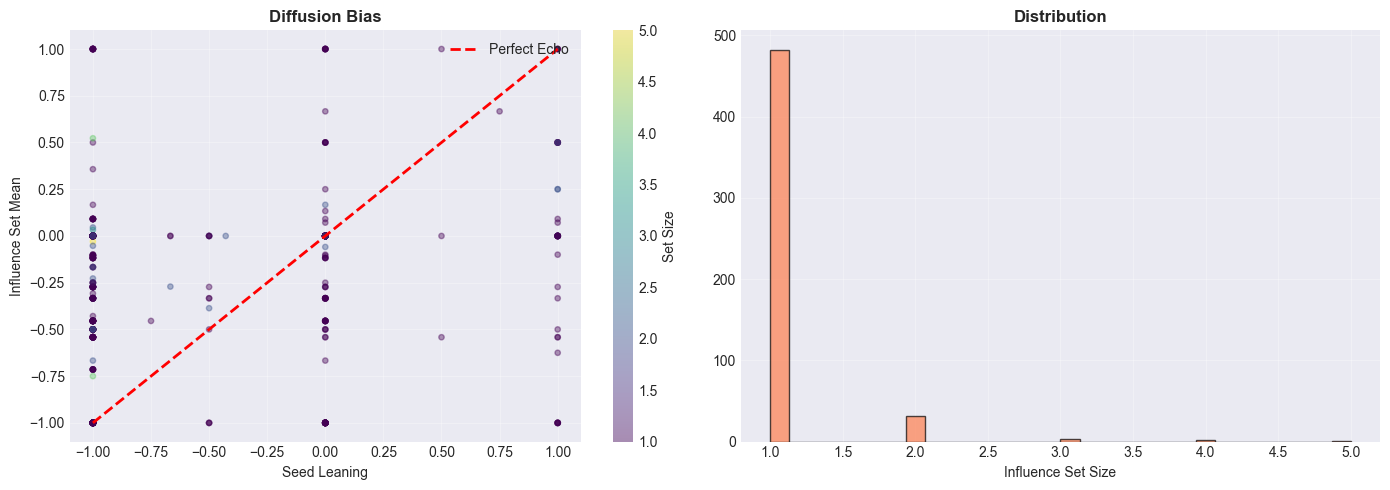

In [100]:
def _ic_run(G, seed_node, p_activate, rng):
    active = {seed_node}
    frontier = [seed_node]
    while frontier:
        u = frontier.pop()
        for v in G.successors(u):
            if v in active:
                continue
            w = float(G[u][v].get("weight", 1.0))
            p = 1.0 - (1.0 - p_activate) ** max(1.0, w)
            if rng.random() < p:
                active.add(v)
                frontier.append(v)
    return active

def simulate_diffusion_bias(G, df_users, p_activate=0.05, n_runs=20, seed=42):
    if isinstance(G, nx.Graph) and not isinstance(G, nx.DiGraph):
        G = nx.DiGraph(G)
    lean = dict(zip(df_users["user"], df_users["lean_scalar"]))
    rows = []
    rng = random.Random(seed)
    for s in tqdm(list(G.nodes()), desc="IC simulate", leave=False):
        seed_lean = lean.get(s, np.nan)
        if np.isnan(seed_lean):
            continue
        union = set()
        for _ in range(n_runs):
            union |= _ic_run(G, s, p_activate, rng)
        union.discard(s)
        vals = [lean[v] for v in union if v in lean and not np.isnan(lean[v])]
        rows.append({
            "seed": s, "seed_lean": seed_lean,
            "infl_mean": float(np.mean(vals)) if vals else np.nan,
            "infl_size": len(vals)
        })
    return pd.DataFrame(rows)

print("Running IC simulation...")
ic_rows = simulate_diffusion_bias(G, df_users, p_activate=0.05, n_runs=20, seed=42)
print(f"Simulated {len(ic_rows):,} seed users")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ic_valid = ic_rows.dropna(subset=['infl_mean'])
sc = axes[0].scatter(ic_valid['seed_lean'], ic_valid['infl_mean'],
                     c=ic_valid['infl_size'].clip(0, 100), cmap='viridis', alpha=0.4, s=15)
axes[0].plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='Perfect Echo')
axes[0].set_xlabel('Seed Leaning'); axes[0].set_ylabel('Influence Set Mean')
axes[0].set_title('Diffusion Bias', fontweight='bold'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
plt.colorbar(sc, ax=axes[0], label='Set Size')

axes[1].hist(ic_valid['infl_size'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Influence Set Size'); axes[1].set_title('Distribution', fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('05_diffusion_bias.png', dpi=150, bbox_inches='tight'); plt.show()

### 9.5 Metrik Kuantitatif Bias Difusi

Selain scatter plot, kita menghitung:
- **Global**: Linear regression (slope, R², p-value), bias ratio, paired t-test, Cohen's d
- **Per-community**: slope, R², one-sample t-test apakah bias ≠ 0

=== GLOBAL DIFFUSION BIAS METRICS ===

  Linear Regression:
    slope     = 0.1630
    intercept = -0.1698
    R²        = 0.0467
    p-value   = 6.61e-07
    std_err   = 0.0324

  Bias Ratio  = 0.5674
  Paired t-test: t=-8.2725, p=1.11e-15
  Cohen's d   = 0.3628

  [*] Slope signifikan (p < 0.05): ada hubungan linear seed_lean -> infl_mean

=== PER-COMMUNITY DIFFUSION METRICS (Top 15) ===
 community  n_seeds  mean_seed_lean  mean_infl_mean      bias     slope  r_squared      ttest_p
         0       31       -0.701613       -0.464809  0.236804 -0.071483   0.093100 1.339680e-02
         1       27       -0.722222       -0.511574  0.210648 -0.022199   0.014637 1.037946e-01
         2       20       -0.325000       -0.012500  0.312500  0.082181   0.177644 3.400199e-02
         4       19       -0.312030        0.003759  0.315789  0.156294   0.103679 2.401573e-02
         7       18       -0.805556       -0.458333  0.347222  0.137838   0.173574 6.705788e-04
         3       17       -0.55

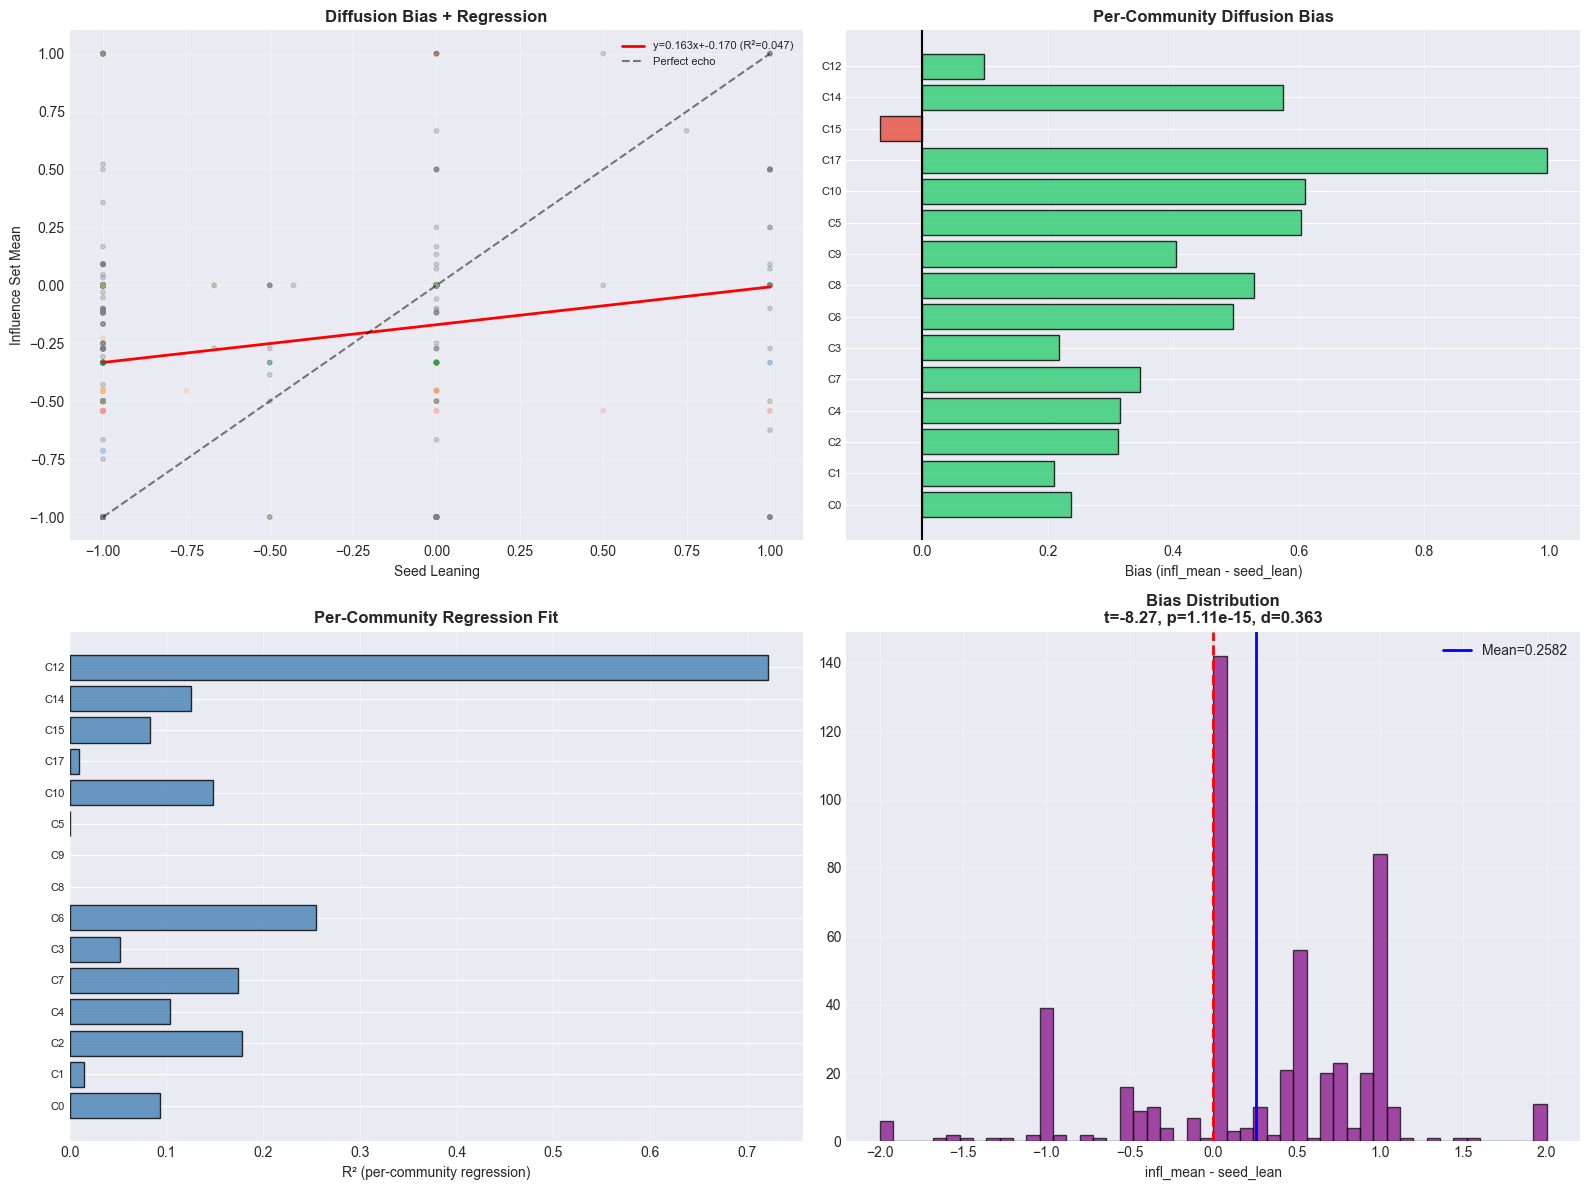

Saved: 05_diffusion_bias.png


In [101]:
# 9.5a. Compute diffusion bias metrics

def _safe_linregress(x, y):
    """linregress that handles constant x (all identical values)."""
    if np.std(x) < 1e-12:
        return 0.0, float(np.mean(y)), 0.0, 1.0, 0.0
    return scipy_stats.linregress(x, y)

ic_valid = ic_rows.dropna(subset=['seed_lean', 'infl_mean']).copy()
x_diff = ic_valid['seed_lean'].values
y_diff = ic_valid['infl_mean'].values

# Global metrics
slope, intercept, r_value, p_value, std_err = _safe_linregress(x_diff, y_diff)
bias_ratio = np.mean(np.abs(y_diff)) / max(np.mean(np.abs(x_diff)), 1e-12)

if len(x_diff) >= 3 and np.std(x_diff - y_diff) > 1e-12:
    t_stat, t_pvalue = scipy_stats.ttest_rel(x_diff, y_diff)
else:
    t_stat, t_pvalue = 0.0, 1.0

diff_vals = y_diff - x_diff
cohens_d = float(np.mean(diff_vals) / max(np.std(diff_vals, ddof=1), 1e-12))

print("=== GLOBAL DIFFUSION BIAS METRICS ===\n")
print(f"  Linear Regression:")
print(f"    slope     = {slope:.4f}")
print(f"    intercept = {intercept:.4f}")
print(f"    R²        = {r_value**2:.4f}")
print(f"    p-value   = {p_value:.2e}")
print(f"    std_err   = {std_err:.4f}")
print(f"\n  Bias Ratio  = {bias_ratio:.4f}")
print(f"  Paired t-test: t={t_stat:.4f}, p={t_pvalue:.2e}")
print(f"  Cohen's d   = {cohens_d:.4f}")

if p_value < 0.05:
    print(f"\n  [*] Slope signifikan (p < 0.05): ada hubungan linear seed_lean -> infl_mean")
else:
    print(f"\n  [ ] Slope TIDAK signifikan (p >= 0.05)")

# Per-community metrics
ic_valid['community'] = ic_valid['seed'].map(communities)
comm_diff_rows = []

for cid, cdf in ic_valid.groupby('community'):
    if len(cdf) < 5:
        continue
    cx, cy = cdf['seed_lean'].values, cdf['infl_mean'].values
    c_slope, c_int, c_r, c_p, c_se = _safe_linregress(cx, cy)
    c_bias = cy - cx
    if np.std(c_bias) > 1e-12 and len(c_bias) >= 3:
        c_t, c_tp = scipy_stats.ttest_1samp(c_bias, 0)
    else:
        c_t, c_tp = 0.0, 1.0
    comm_diff_rows.append({
        'community': cid, 'n_seeds': len(cdf),
        'mean_seed_lean': float(np.mean(cx)), 'mean_infl_mean': float(np.mean(cy)),
        'bias': float(np.mean(c_bias)), 'slope': float(c_slope),
        'r_squared': float(c_r**2), 'ttest_p': float(c_tp),
    })

df_diff_comm = pd.DataFrame(comm_diff_rows).sort_values('n_seeds', ascending=False)
print("\n=== PER-COMMUNITY DIFFUSION METRICS (Top 15) ===")
print(df_diff_comm.head(15).to_string(index=False))

# 9.5b. Visualizations (4 subplots)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Scatter + regression line, colored by community
comm_colors = {}
unique_comms = ic_valid['community'].dropna().unique()
cmap_arr = plt.cm.tab20(np.linspace(0, 1, min(20, len(unique_comms))))
for i, c in enumerate(unique_comms[:20]):
    comm_colors[c] = cmap_arr[i]

colors = [comm_colors.get(c, (0.5, 0.5, 0.5, 0.5)) for c in ic_valid['community']]
axes[0, 0].scatter(x_diff, y_diff, c=colors, alpha=0.3, s=10)
x_line = np.linspace(-1, 1, 100)
axes[0, 0].plot(x_line, slope * x_line + intercept, 'r-', linewidth=2,
                label=f'y={slope:.3f}x+{intercept:.3f} (R²={r_value**2:.3f})')
axes[0, 0].plot([-1, 1], [-1, 1], 'k--', alpha=0.5, label='Perfect echo')
axes[0, 0].set_xlabel('Seed Leaning')
axes[0, 0].set_ylabel('Influence Set Mean')
axes[0, 0].set_title('Diffusion Bias + Regression', fontweight='bold')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# 2) Per-community bias bar chart
top_comms = df_diff_comm.head(15)
y_pos = np.arange(len(top_comms))
colors_bar = ['#2ecc71' if b > 0 else '#e74c3c' for b in top_comms['bias']]
axes[0, 1].barh(y_pos, top_comms['bias'].values, color=colors_bar, alpha=0.8, edgecolor='black')
axes[0, 1].set_yticks(y_pos)
axes[0, 1].set_yticklabels([f"C{int(c)}" for c in top_comms['community']], fontsize=8)
axes[0, 1].axvline(x=0, color='black', linestyle='-')
axes[0, 1].set_xlabel('Bias (infl_mean - seed_lean)')
axes[0, 1].set_title('Per-Community Diffusion Bias', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3) Per-community R² bar chart
axes[1, 0].barh(y_pos, top_comms['r_squared'].values, color='steelblue', alpha=0.8, edgecolor='black')
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels([f"C{int(c)}" for c in top_comms['community']], fontsize=8)
axes[1, 0].set_xlabel('R² (per-community regression)')
axes[1, 0].set_title('Per-Community Regression Fit', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4) Histogram of (
# infl_mean - seed_lean) + t-test annotation
axes[1, 1].hist(diff_vals, bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].axvline(x=np.mean(diff_vals), color='blue', linestyle='-', linewidth=2,
                    label=f'Mean={np.mean(diff_vals):.4f}')
axes[1, 1].set_xlabel('infl_mean - seed_lean')
axes[1, 1].set_title(f'Bias Distribution\nt={t_stat:.2f}, p={t_pvalue:.2e}, d={cohens_d:.3f}',
                      fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_diffusion_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_diffusion_bias.png")

---
## 10. Community Analysis: Pro vs Contra

In [102]:
# 10a. Classify communities
def classify_communities_by_stance(G, df_users, communities, lean_col="lean_scalar", threshold=0.2):
    lean_dict = dict(zip(df_users['user'], df_users[lean_col]))
    community_leaning = defaultdict(list)
    for user, comm_id in communities.items():
        if user in lean_dict and not np.isnan(lean_dict[user]):
            community_leaning[comm_id].append(lean_dict[user])
    community_stance = {}
    for comm_id, leanings in community_leaning.items():
        avg = np.mean(leanings)
        if avg > threshold: community_stance[comm_id] = 'pro'
        elif avg < -threshold: community_stance[comm_id] = 'contra'
        else: community_stance[comm_id] = 'neutral'
    return community_stance

def analyze_pro_contra_communities(G, df_users, communities, lean_col="lean_scalar", threshold=0.2):
    lean_dict = dict(zip(df_users['user'], df_users[lean_col]))
    community_stance = classify_communities_by_stance(G, df_users, communities, lean_col, threshold)
    results = []
    for comm_id in set(communities.values()):
        members = [u for u, c in communities.items() if c == comm_id]
        leanings = [lean_dict.get(u, np.nan) for u in members]
        leanings = [x for x in leanings if not np.isnan(x)]
        if not leanings: continue
        internal = external = 0
        for u in members:
            if u in G:
                for v in (G.successors(u) if isinstance(G, nx.DiGraph) else G.neighbors(u)):
                    if communities.get(v) == comm_id: internal += 1
                    else: external += 1
        results.append({
            'community_id': comm_id, 'stance': community_stance.get(comm_id, 'neutral'),
            'size': len(members), 'avg_leaning': np.mean(leanings), 'std_leaning': np.std(leanings),
            'internal_edges': internal, 'external_edges': external,
            'modularity': internal / (internal + external) if (internal + external) > 0 else 0
        })
    return pd.DataFrame(results).sort_values('size', ascending=False)

community_stance = classify_communities_by_stance(G, df_users, communities)
df_communities = analyze_pro_contra_communities(G, df_users, communities)

stance_counts = pd.Series(community_stance.values()).value_counts()
print("Distribusi Community Stance:")
print(stance_counts)
print(f"\nTop 15 communities:")
print(df_communities[['community_id', 'stance', 'size', 'avg_leaning', 'modularity']].head(15))

Distribusi Community Stance:
contra     137
neutral     46
pro         25
Name: count, dtype: int64

Top 15 communities:
    community_id  stance  size  avg_leaning  modularity
0              0  contra    51    -0.651070    1.000000
1              1  contra    41    -0.561992    0.975610
2              2  contra    37    -0.243243    1.000000
3              3  contra    33    -0.520202    0.971429
4              4  contra    28    -0.318878    0.966667
5              5  contra    27    -0.450617    1.000000
6              6  contra    26    -0.380836    0.925926
7              7  contra    26    -0.769231    0.925926
8              8  contra    26    -0.423077    0.931034
9              9  contra    24    -0.448864    1.000000
10            10  contra    23    -0.586957    0.920000
11            11  contra    22    -0.219697    0.814815
12            12  contra    21    -0.714286    0.909091
13            13  contra    19    -0.421053    1.000000
14            14  contra    18    -0.78

=== DETAILED COMMUNITY CLASSIFICATION ===
 community_id  size stance  avg_leaning  std_leaning  pct_pro  pct_contra  pct_neutral  confidence
            0    51 contra    -0.651070     0.507795 0.019608    0.686275     0.294118    1.282150
            1    41 contra    -0.561992     0.708729 0.146341    0.707317     0.146341    0.792957
            2    37 contra    -0.243243     0.643277 0.135135    0.378378     0.486486    0.378131
            3    33 contra    -0.520202     0.537731 0.030303    0.606061     0.363636    0.967403
            4    28 contra    -0.318878     0.600195 0.107143    0.464286     0.428571    0.531290
            5    27 contra    -0.450617     0.551494 0.037037    0.518519     0.444444    0.817085
            7    26 contra    -0.769231     0.397849 0.000000    0.807692     0.192308    1.933473
            8    26 contra    -0.423077     0.689095 0.115385    0.538462     0.346154    0.613960
            6    26 contra    -0.380836     0.686877 0.115385    0.

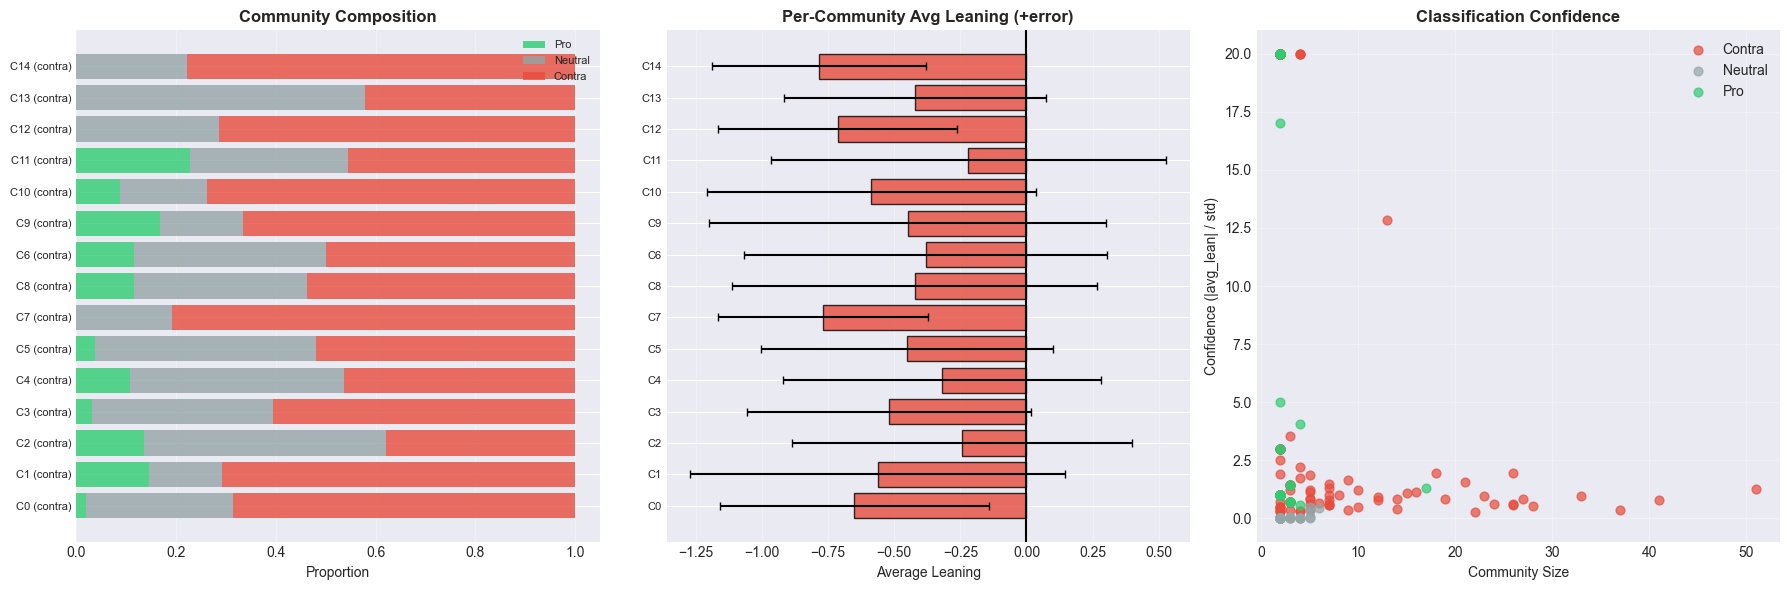

In [103]:
# 10a.2 Detailed Community Classification

def classify_communities_detailed(G, df_users, communities, threshold=0.2, lean_col='lean_scalar'):
    """Classify communities with detailed metrics including composition percentages."""
    lean_dict = dict(zip(df_users['user'], df_users[lean_col]))
    eps = 1e-12
    comm_members = defaultdict(list)
    for user, cid in communities.items():
        comm_members[cid].append(user)

    results = []
    for cid, members in comm_members.items():
        leanings = [lean_dict.get(u, np.nan) for u in members]
        leanings = [x for x in leanings if not np.isnan(x)]
        if not leanings:
            continue

        avg_lean = float(np.mean(leanings))
        std_lean = float(np.std(leanings))
        med_lean = float(np.median(leanings))

        n_pro = sum(1 for x in leanings if x > threshold)
        n_contra = sum(1 for x in leanings if x < -threshold)
        n_neutral = len(leanings) - n_pro - n_contra
        total = len(leanings)

        stance = 'pro' if avg_lean > threshold else ('contra' if avg_lean < -threshold else 'neutral')

        member_set = set(members)
        internal_edges = external_edges = 0
        for u in members:
            if u not in G: continue
            nbrs = list(G.successors(u)) if isinstance(G, nx.DiGraph) else list(G.neighbors(u))
            for v in nbrs:
                if v in member_set: internal_edges += 1
                else: external_edges += 1

        results.append({
            'community_id': cid, 'size': len(members), 'stance': stance,
            'avg_leaning': avg_lean, 'std_leaning': std_lean, 'median_leaning': med_lean,
            'pct_pro': n_pro/total, 'pct_contra': n_contra/total, 'pct_neutral': n_neutral/total,
            'internal_edges': internal_edges, 'external_edges': external_edges,
            'modularity_contribution': internal_edges / (internal_edges + external_edges + eps),
            'confidence': abs(avg_lean) / (std_lean + eps),
        })

    return pd.DataFrame(results).sort_values('size', ascending=False).reset_index(drop=True)

df_communities_detailed = classify_communities_detailed(G, df_users, communities)

print("=== DETAILED COMMUNITY CLASSIFICATION ===")
print(df_communities_detailed[['community_id', 'size', 'stance', 'avg_leaning', 'std_leaning',
                                'pct_pro', 'pct_contra', 'pct_neutral', 'confidence']].head(15).to_string(index=False))

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Stacked bar chart: composition per community
top_n = min(15, len(df_communities_detailed))
top_df = df_communities_detailed.head(top_n)
y_pos = np.arange(top_n)
axes[0].barh(y_pos, top_df['pct_pro'], color='#2ecc71', alpha=0.8, label='Pro')
axes[0].barh(y_pos, top_df['pct_neutral'], left=top_df['pct_pro'], color='#95a5a6', alpha=0.8, label='Neutral')
axes[0].barh(y_pos, top_df['pct_contra'], left=top_df['pct_pro']+top_df['pct_neutral'],
             color='#e74c3c', alpha=0.8, label='Contra')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([f"C{int(c)} ({s})" for c, s in zip(top_df['community_id'], top_df['stance'])], fontsize=8)
axes[0].set_xlabel('Proportion')
axes[0].set_title('Community Composition', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# 2) Horizontal bar chart: avg_leaning with error bars
colors_lean = ['#2ecc71' if s == 'pro' else ('#e74c3c' if s == 'contra' else '#95a5a6')
               for s in top_df['stance']]
axes[1].barh(y_pos, top_df['avg_leaning'], xerr=top_df['std_leaning'], color=colors_lean,
             alpha=0.8, edgecolor='black', capsize=3)
axes[1].axvline(x=0, color='black', linestyle='-')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([f"C{int(c)}" for c in top_df['community_id']], fontsize=8)
axes[1].set_xlabel('Average Leaning')
axes[1].set_title('Per-Community Avg Leaning (+error)', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# 3) Confidence vs size scatter
cmap_stance = {'pro': '#2ecc71', 'contra': '#e74c3c', 'neutral': '#95a5a6'}
for stance, group in df_communities_detailed.groupby('stance'):
    axes[2].scatter(group['size'], group['confidence'].clip(0, 20), s=40, alpha=0.7,
                    color=cmap_stance.get(stance, 'gray'), label=stance.capitalize())
axes[2].set_xlabel('Community Size')
axes[2].set_ylabel('Confidence (|avg_lean| / std)')
axes[2].set_title('Classification Confidence', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [104]:
# 10b. Central Users -- dengan USERNAME
def identify_central_users(G, df_users, communities, community_stance, top_n=50, lean_col="lean_scalar"):
    print("Computing centrality measures...")
    degree_cent = nx.degree_centrality(G)
    betweenness_cent = nx.betweenness_centrality(G, k=min(500, G.number_of_nodes()))
    pagerank = nx.pagerank(G, max_iter=100)
    try: eigen_cent = nx.eigenvector_centrality(G, max_iter=100)
    except: eigen_cent = pagerank

    lean_dict = dict(zip(df_users['user'], df_users[lean_col]))
    results = {'pro': [], 'contra': [], 'neutral': []}

    for user, comm_id in communities.items():
        if user not in G or user not in lean_dict: continue
        if np.isnan(lean_dict[user]): continue
        stance = community_stance.get(comm_id, 'neutral')
        results[stance].append({
            'username': get_username(user),
            'community_id': comm_id, 'leaning': lean_dict[user],
            'degree_centrality': degree_cent.get(user, 0),
            'betweenness_centrality': betweenness_cent.get(user, 0),
            'pagerank': pagerank.get(user, 0),
            'eigenvector_centrality': eigen_cent.get(user, 0),
            'degree': G.degree(user)
        })

    top_users = {}
    for stance in ['pro', 'contra', 'neutral']:
        if results[stance]:
            d = pd.DataFrame(results[stance])
            for col in ['degree_centrality', 'pagerank', 'betweenness_centrality', 'eigenvector_centrality']:
                mx = d[col].max()
                d[f'{col}_n'] = d[col] / mx if mx > 0 else 0
            d['influence_score'] = (0.3*d['degree_centrality_n'] + 0.3*d['pagerank_n'] +
                                    0.2*d['betweenness_centrality_n'] + 0.2*d['eigenvector_centrality_n'])
            top_users[stance] = d.sort_values('influence_score', ascending=False)
    return top_users

top_users = identify_central_users(G, df_users, communities, community_stance, top_n=50)

for stance in ['pro', 'contra']:
    if stance in top_users and len(top_users[stance]) > 0:
        print(f"\n{'='*70}")
        print(f"TOP 10 INFLUENTIAL USERS - {stance.upper()}")
        print(f"{'='*70}")
        cols = ['username', 'leaning', 'influence_score', 'degree']
        # Filter: hanya user dengan username asli (bukan @ID)
        real = top_users[stance][~top_users[stance]['username'].str.startswith('@')]
        show = real[cols].head(10) if len(real) >= 5 else top_users[stance][cols].head(10)
        print(show.to_string(index=False))

Computing centrality measures...

TOP 10 INFLUENTIAL USERS - PRO
       username  leaning  influence_score  degree
   kemendespdtt      0.5         0.715510      15
    yhendarsyah      1.0         0.294260       1
       Rohmahdg      0.0         0.289648       2
    B0c4hkeling      0.0         0.181954       1
    Susansiti96      1.0         0.181954       1
      FOODFESS2      0.0         0.163281       3
panah_bintangku      0.5         0.136464       3
    ipoksamidub      1.0         0.116464       2
   poldajateng_      0.0         0.116464       2
     DITJEN_PAS      0.0         0.116464       2

TOP 10 INFLUENTIAL USERS - CONTRA
      username   leaning  influence_score  degree
  CNNIndonesia -0.454545         0.600003      54
    KemenkesRI  0.000000         0.595634      26
      detikcom -0.541667         0.450371      41
__Sridiana_3va  0.000000         0.412221      20
  FaheemYounus  0.000000         0.409123      36
   tirta_hudhi -0.333333         0.346520      31


In [105]:
# 10c. Bridge Users - dengan USERNAME
def analyze_cross_community_bridges(G, communities, community_stance, top_n=20):
    bridge_scores = []
    for user in G.nodes():
        if user not in communities: continue
        user_stance = community_stance.get(communities[user], 'neutral')
        if user_stance == 'neutral': continue
        connections = {'pro': 0, 'contra': 0, 'neutral': 0}
        nbrs = list(G.successors(user)) + list(G.predecessors(user)) if isinstance(G, nx.DiGraph) else list(G.neighbors(user))
        for v in nbrs:
            if v in communities:
                connections[community_stance.get(communities[v], 'neutral')] += 1
        opposite = 'contra' if user_stance == 'pro' else 'pro'
        total = sum(connections.values())
        if total > 0:
            bridge_scores.append({
                'username': get_username(user), 'stance': user_stance,
                'total_connections': total,
                'pro_connections': connections['pro'],
                'contra_connections': connections['contra'],
                'bridge_score': connections[opposite] / total
            })
    return pd.DataFrame(bridge_scores).sort_values('bridge_score', ascending=False).head(top_n)

df_bridges = analyze_cross_community_bridges(G, communities, community_stance, top_n=20)
print("BRIDGE USERS (Connecting Pro <-> Contra)")
if len(df_bridges) > 0:
    print(df_bridges[['username','stance','bridge_score','total_connections']].head(10).to_string(index=False))

BRIDGE USERS (Connecting Pro <-> Contra)
      username stance  bridge_score  total_connections
    yatieperry contra           0.0                  1
      501Awani contra           0.0                 12
 HAIGunawanSE1 contra           0.0                  1
      fadlizon contra           0.0                 11
Panjol40190784 contra           0.0                  2
 OposisiCerdas contra           0.0                 10
      mariniiy contra           0.0                  1
    blogdokter contra           0.0                  3
     EndahWook contra           0.0                  1
  CNNIndonesia contra           0.0                 54


In [106]:
# 10d. Topic Shifts -- dengan USERNAME
def analyze_topic_shifts(df_raw, user_col='from_id', sentiment_col='gpt_label', min_posts=10):
    sentiment_map = {'negative': -1, 'neutral': 0, 'positive': 1}
    d = df_raw.copy()
    d['_sn'] = d[sentiment_col].astype(str).str.lower().apply(lambda x: sentiment_map.get(x, 0))
    results = []
    for uid, udf in d.groupby(user_col):
        if len(udf) < min_posts: continue
        sents = udf['_sn'].values
        mid = len(sents) // 2
        early, late = np.mean(sents[:max(mid,1)]), np.mean(sents[max(mid,1):])
        shift = late - early
        shift_type = 'stable'
        if abs(shift) > 0.3:
            if shift > 0 and early < -0.2 and late > 0.2: shift_type = 'contra_to_pro'
            elif shift < 0 and early > 0.2 and late < -0.2: shift_type = 'pro_to_contra'
            elif shift > 0: shift_type = 'negative_to_positive'
            elif shift < 0: shift_type = 'positive_to_negative'
        results.append({'username': get_username(uid), 'n_posts': len(udf),
                        'early_sentiment': early, 'late_sentiment': late,
                        'sentiment_shift': shift, 'shift_type': shift_type,
                        'shift_magnitude': abs(shift)})
    return pd.DataFrame(results)

df_shifts = analyze_topic_shifts(df, user_col='from_id', sentiment_col='gpt_label')
print(f"Users analyzed: {len(df_shifts):,}")
print(f"Significant shifts (> 0.3): {(df_shifts['shift_magnitude'] > 0.3).sum():,}")
print(f"\n{df_shifts['shift_type'].value_counts()}")

Users analyzed: 27
Significant shifts (> 0.3): 6

shift_type
stable                  21
positive_to_negative     4
negative_to_positive     1
contra_to_pro            1
Name: count, dtype: int64


---
## 11. Visualisasi Komprehensif

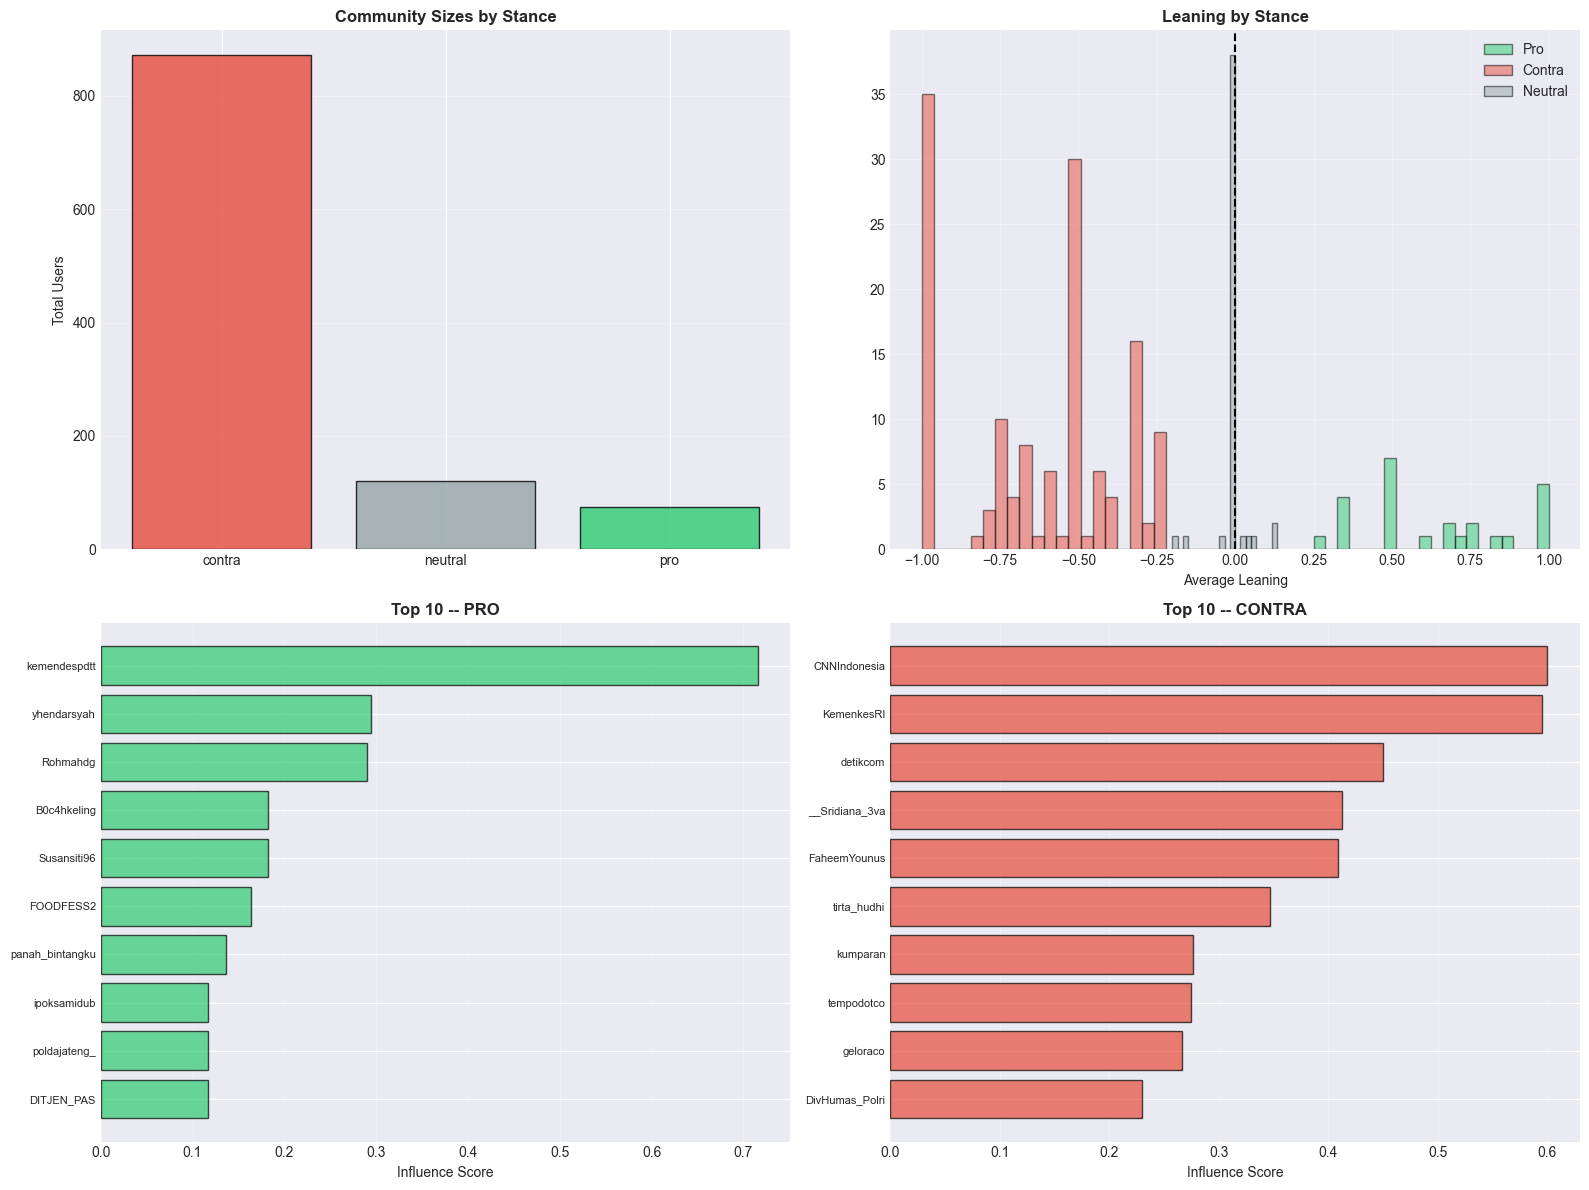

Saved: 06_pro_contra.png


In [107]:
# 11a. Pro vs Contra
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
stance_sizes = df_communities.groupby('stance')['size'].sum()
cmap_colors = {'pro': '#2ecc71', 'contra': '#e74c3c', 'neutral': '#95a5a6'}
axes[0,0].bar(stance_sizes.index, stance_sizes.values,
              color=[cmap_colors.get(s,'gray') for s in stance_sizes.index], alpha=0.8, edgecolor='black')
axes[0,0].set_ylabel('Total Users')
axes[0,0].set_title('Community Sizes by Stance', fontweight='bold')
axes[0,0].grid(True, alpha=0.3, axis='y')

for st, c in cmap_colors.items():
    sd = df_communities[df_communities['stance']==st]
    if len(sd) > 0:
        axes[0,1].hist(sd['avg_leaning'], bins=20, alpha=0.5, label=st.capitalize(), color=c, edgecolor='black')
axes[0,1].axvline(x=0, color='black', linestyle='--')
axes[0,1].set_xlabel('Average Leaning')
axes[0,1].set_title('Leaning by Stance', fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

for i, (stance, color) in enumerate([('pro', '#2ecc71'), ('contra', '#e74c3c')]):
    ax = axes[1, i]
    if stance in top_users and len(top_users[stance]) > 0:
        # Filter: hanya user dengan username asli (bukan @ID)
        _f = top_users[stance][~top_users[stance]['username'].str.startswith('@')]
        dp = _f.head(10).copy() if len(_f) >= 5 else top_users[stance].head(10).copy()
        y = np.arange(len(dp))
        ax.barh(y, dp['influence_score'].values, color=color, alpha=0.7, edgecolor='black')
        ax.set_yticks(y)
        ax.set_yticklabels([str(u) for u in dp['username'].values], fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel('Influence Score')
        ax.set_title(f'Top 10 -- {stance.upper()}', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('06_pro_contra.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_pro_contra.png")

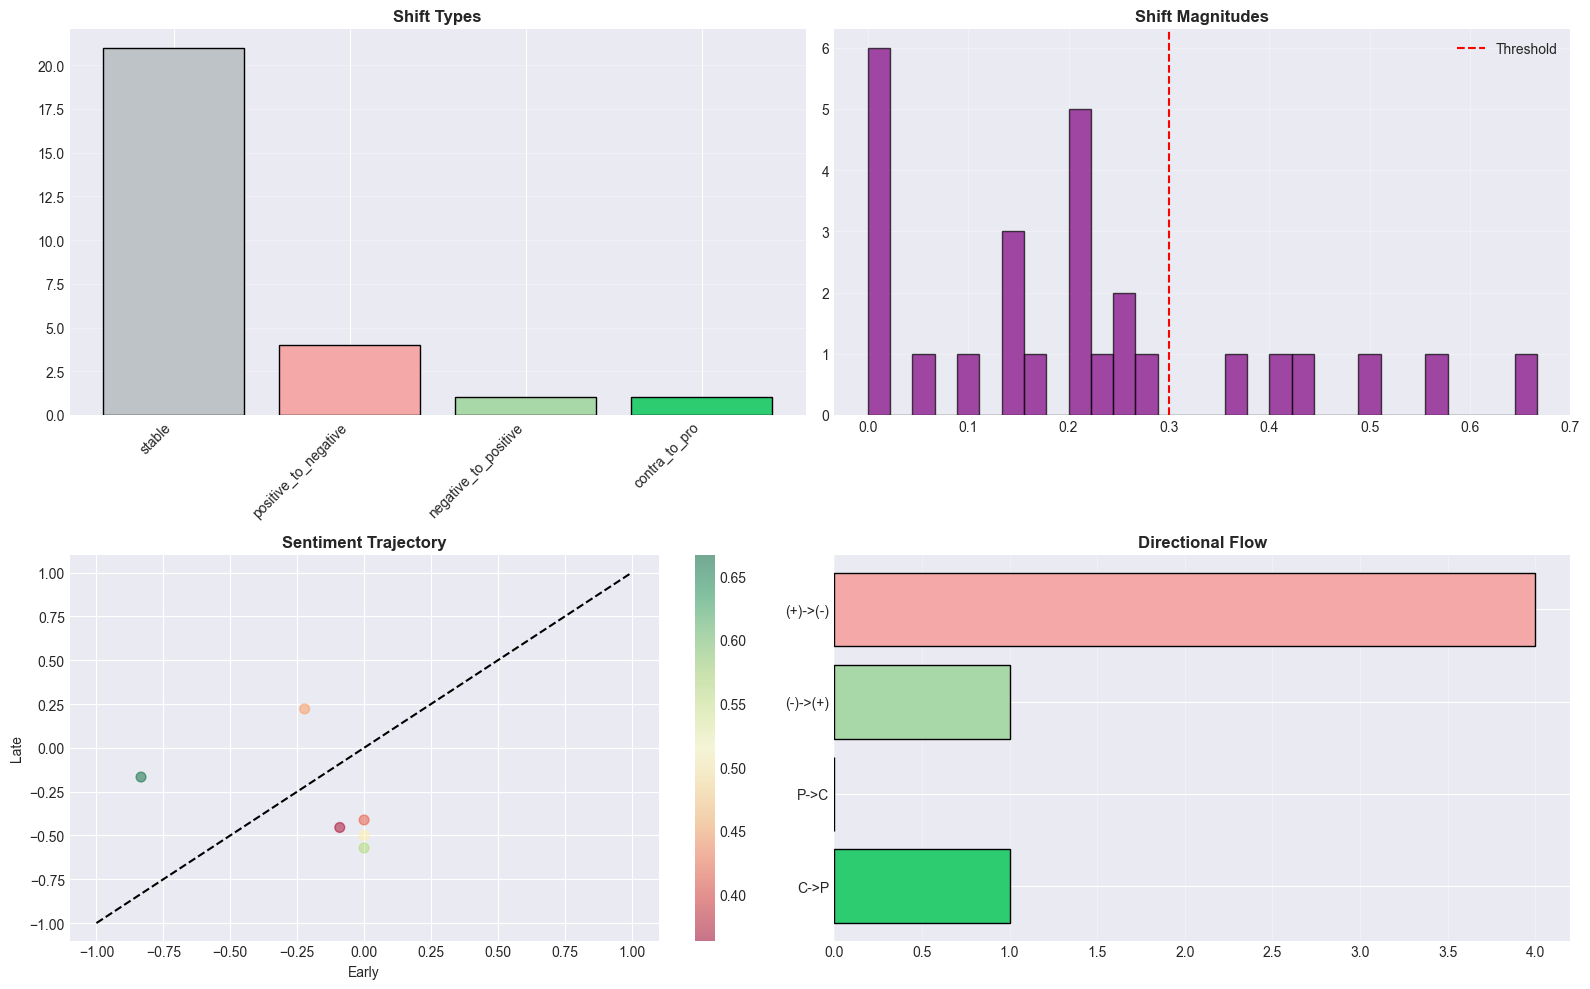

In [108]:
# 11b. Topic Shifts
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
shift_counts = df_shifts['shift_type'].value_counts()
sc_colors = {'contra_to_pro':'#2ecc71','pro_to_contra':'#e74c3c','negative_to_positive':'#a8d8a8','positive_to_negative':'#f5a8a8','stable':'#bdc3c7'}
axes[0,0].bar(range(len(shift_counts)), shift_counts.values, color=[sc_colors.get(s,'gray') for s in shift_counts.index], edgecolor='black')
axes[0,0].set_xticks(range(len(shift_counts))); axes[0,0].set_xticklabels(shift_counts.index, rotation=45, ha='right')
axes[0,0].set_title('Shift Types', fontweight='bold'); axes[0,0].grid(True, alpha=0.3, axis='y')

axes[0,1].hist(df_shifts['shift_magnitude'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[0,1].axvline(x=0.3, color='r', linestyle='--', label='Threshold'); axes[0,1].set_title('Shift Magnitudes', fontweight='bold'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

sig = df_shifts[df_shifts['shift_magnitude']>0.3]
if len(sig) > 0:
    sc = axes[1,0].scatter(sig['early_sentiment'], sig['late_sentiment'], alpha=0.5, s=50, c=sig['shift_magnitude'], cmap='RdYlGn')
    axes[1,0].plot([-1,1],[-1,1],'k--'); axes[1,0].set_xlabel('Early'); axes[1,0].set_ylabel('Late')
    axes[1,0].set_title('Sentiment Trajectory', fontweight='bold'); plt.colorbar(sc, ax=axes[1,0])

flow = {'C->P': (df_shifts['shift_type']=='contra_to_pro').sum(), 'P->C': (df_shifts['shift_type']=='pro_to_contra').sum(),
        '(-)->(+)': (df_shifts['shift_type']=='negative_to_positive').sum(), '(+)->(-)': (df_shifts['shift_type']=='positive_to_negative').sum()}
axes[1,1].barh(list(flow.keys()), list(flow.values()), color=['#2ecc71','#e74c3c','#a8d8a8','#f5a8a8'], edgecolor='black')
axes[1,1].set_title('Directional Flow', fontweight='bold'); axes[1,1].grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.savefig('07_shifts.png', dpi=150, bbox_inches='tight'); plt.show()

Visualizing top-500 degree subgraph: 500 nodes, 423 edges


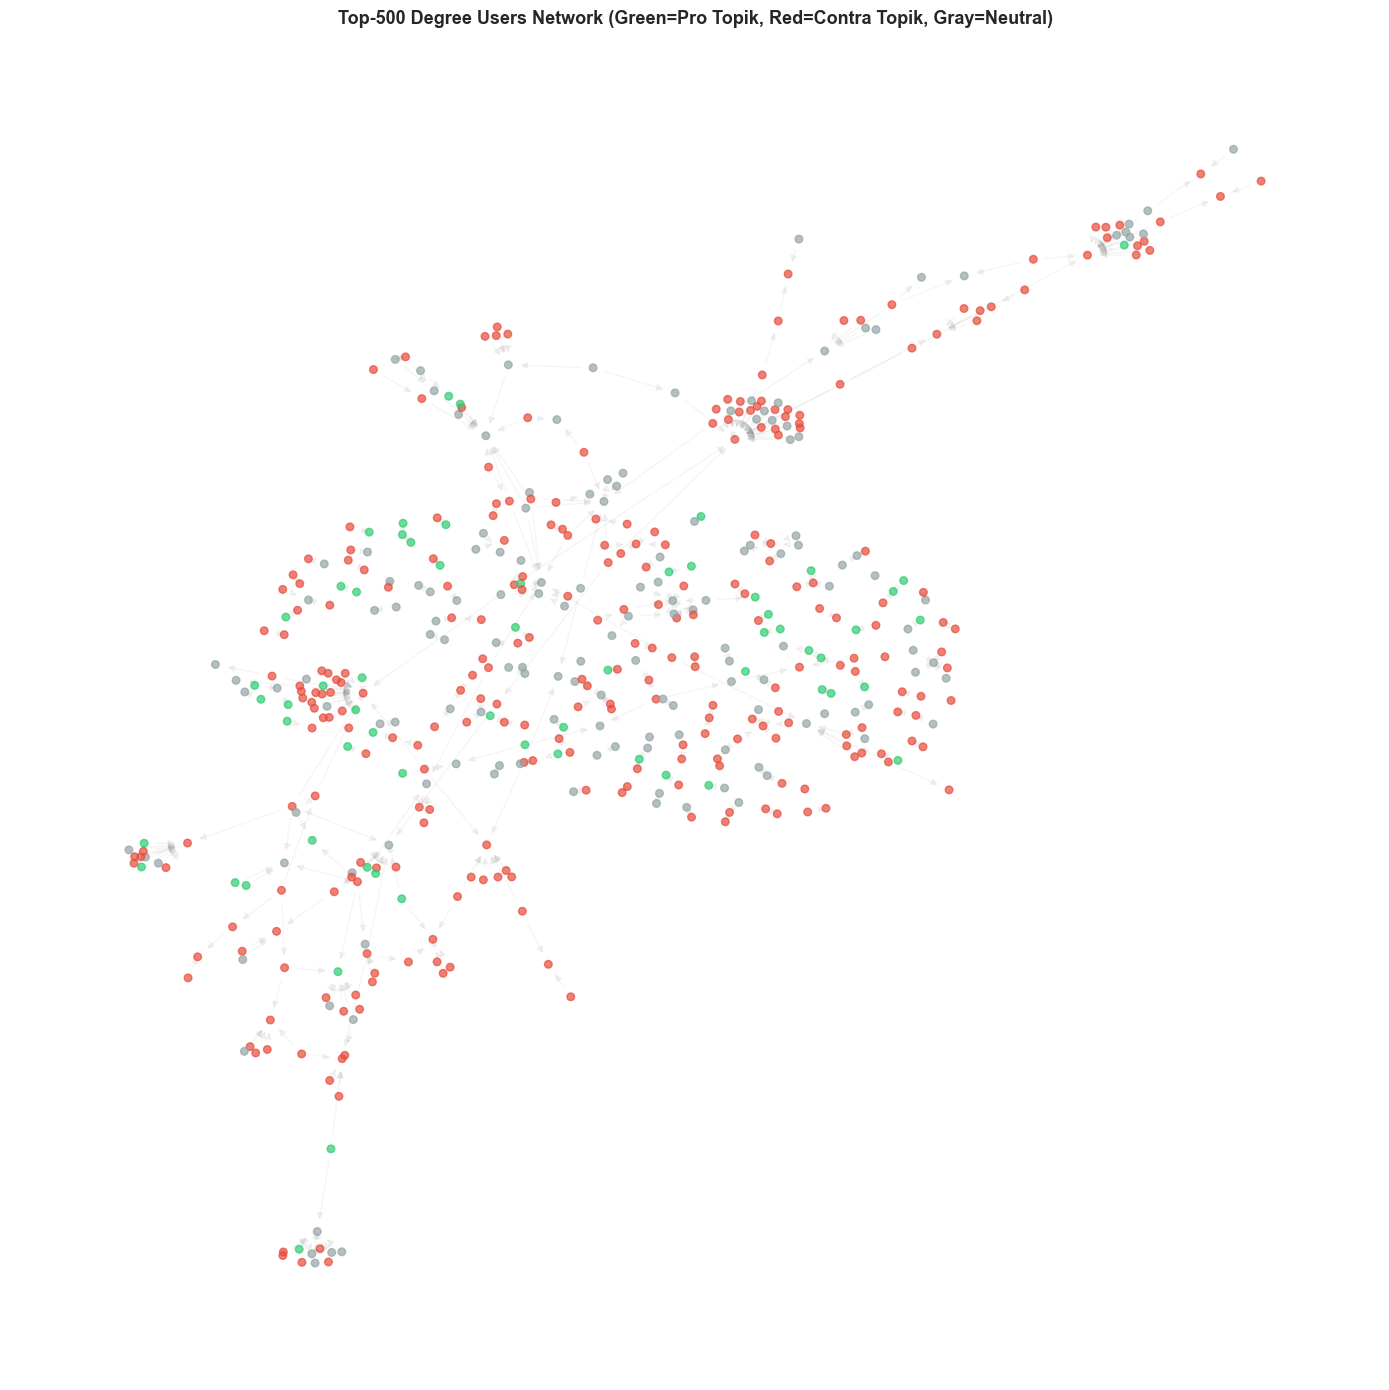

In [109]:
# 11c. Network graph
MAX_VIS = 500

degree_dict = dict(G.degree())
top_degree_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:MAX_VIS]
G_vis = G.subgraph(top_degree_nodes).copy()

print(f"Visualizing top-{MAX_VIS} degree subgraph: {G_vis.number_of_nodes()} nodes, {G_vis.number_of_edges()} edges")

lean_dict = dict(zip(df_users["user"], df_users["lean_scalar"]))

fig, ax = plt.subplots(figsize=(14, 14))
pos = nx.spring_layout(G_vis, seed=42, k=2.0/np.sqrt(G_vis.number_of_nodes()+1), iterations=80)

node_colors = []
for n in G_vis.nodes():
    l = lean_dict.get(n, 0)
    if l > 0.2: node_colors.append('#2ecc71')
    elif l < -0.2: node_colors.append('#e74c3c')
    else: node_colors.append('#95a5a6')

nx.draw_networkx_edges(G_vis, pos, alpha=0.08, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(G_vis, pos, node_color=node_colors, node_size=30, alpha=0.7, ax=ax)
ax.set_title(f'Top-{MAX_VIS} Degree Users Network (Green=Pro Topik, Red=Contra Topik, Gray=Neutral)', fontweight='bold', fontsize=13)
ax.axis('off')
plt.tight_layout(); plt.savefig('08_network.png', dpi=150, bbox_inches='tight'); plt.show()

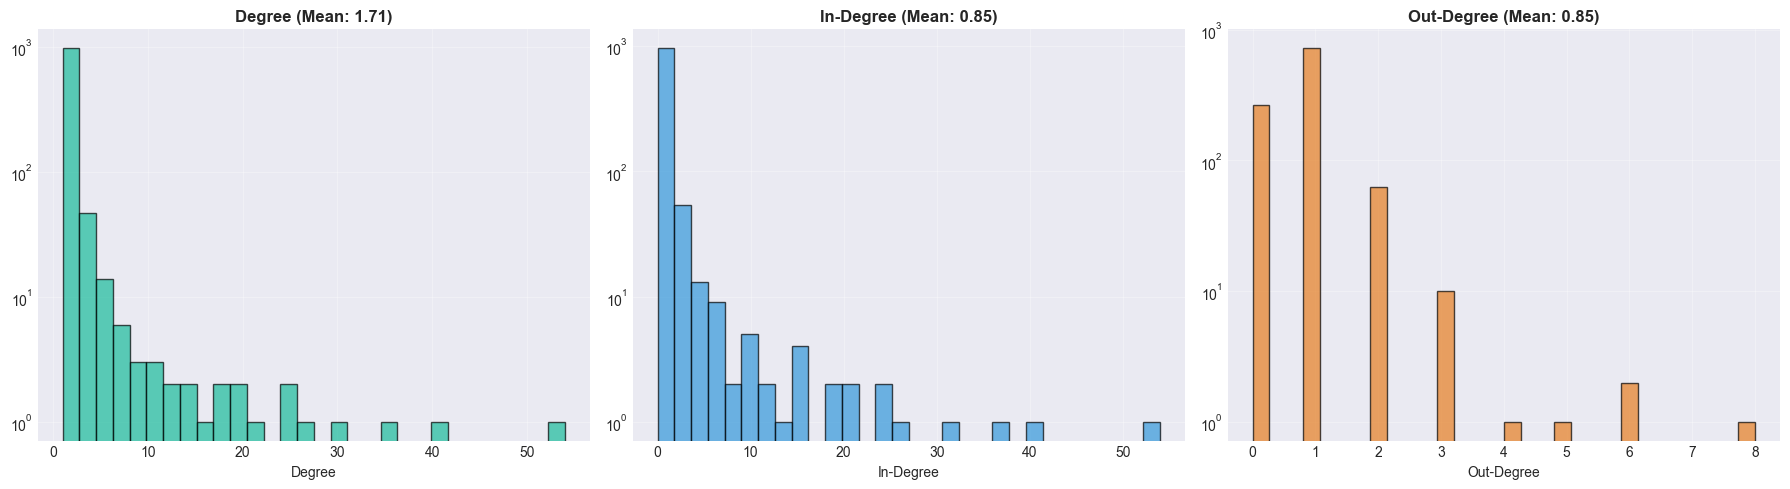

In [110]:
# 11d. Degree analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
degs = [G.degree(n) for n in G.nodes()]
in_degs = [G.in_degree(n) for n in G.nodes()]
out_degs = [G.out_degree(n) for n in G.nodes()]

for ax, data_arr, title, color in [(axes[0], degs, 'Degree', '#1abc9c'), (axes[1], in_degs, 'In-Degree', '#3498db'), (axes[2], out_degs, 'Out-Degree', '#e67e22')]:
    ax.hist(data_arr, bins=30, color=color, alpha=0.7, edgecolor='black')
    ax.set_xlabel(title); ax.set_title(f'{title} (Mean: {np.mean(data_arr):.2f})', fontweight='bold')
    ax.set_yscale('log'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('09_degrees.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 12. Summary Report

In [111]:
print(f"""
{'='*80}
ECHO CHAMBER RATIO (ECR 2.0) -- COMPLETE ANALYSIS REPORT
{'='*80}
Topik: 'Vaksinasi'
Pro   = SETUJU Vaksinasi (sentimen positif dominan) -> lean_scalar > 0
Contra = TIDAK SETUJU Vaksinasi (sentimen negatif dominan) -> lean_scalar < 0

DATASET OVERVIEW
{'-'*80}
  Total Records          : {len(df):,}
  Unique Users (content) : {df['from_id'].nunique():,}
  Users in Network       : {n_nodes:,}
  Total Interactions     : {n_edges:,}
  Network Density        : {density:.6f}

COMMUNITY DETECTION
{'-'*80}
  Algorithm              : {'Leiden' if _HAS_LEIDEN else 'Louvain'}
  Resolution             : {resolution:.3f}
  Communities Found      : {n_communities}
  Pro Communities        : {stance_counts.get('pro', 0)}
  Contra Communities     : {stance_counts.get('contra', 0)}
  Neutral Communities    : {stance_counts.get('neutral', 0)}

ECR 2.0 RESULTS
{'-'*80}
  Intra-community Agr.   : {ecr2.intra:.4f}
  Inter-community Agr.   : {ecr2.inter:.4f}
  ECR Ratio (Agreement)  : {ecr2.ratio:.4f}
  ECR Ratio (Cosine)     : {ecr_cosine:.4f}
  Homophily (Pearson r)  : {ecr2.homophily_r:.4f}
  Empirical Threshold    : {threshold:.4f}

  * KESIMPULAN: {classification}

DIFFUSION BIAS
{'-'*80}
  Regression slope       : {slope:.4f} (p={p_value:.2e})
  R²                     : {r_value**2:.4f}
  Bias Ratio             : {bias_ratio:.4f}
  Paired t-test          : t={t_stat:.4f}, p={t_pvalue:.2e}
  Cohen's d              : {cohens_d:.4f}

TOPIC SHIFTS
{'-'*80}
  Users Analyzed         : {len(df_shifts):,}
  Significant Shifts     : {(df_shifts['shift_magnitude'] > 0.3).sum():,}
  Contra -> Pro          : {(df_shifts['shift_type'] == 'contra_to_pro').sum():,}
  Pro -> Contra          : {(df_shifts['shift_type'] == 'pro_to_contra').sum():,}
""")


ECHO CHAMBER RATIO (ECR 2.0) -- COMPLETE ANALYSIS REPORT
Topik: 'Vaksinasi'
Pro   = SETUJU Vaksinasi (sentimen positif dominan) -> lean_scalar > 0
Contra = TIDAK SETUJU Vaksinasi (sentimen negatif dominan) -> lean_scalar < 0

DATASET OVERVIEW
--------------------------------------------------------------------------------
  Total Records          : 10,000
  Unique Users (content) : 8,654
  Users in Network       : 1,066
  Total Interactions     : 909
  Network Density        : 0.000801

COMMUNITY DETECTION
--------------------------------------------------------------------------------
  Algorithm              : Leiden
  Resolution             : 3.028
  Communities Found      : 208
  Pro Communities        : 25
  Contra Communities     : 137
  Neutral Communities    : 46

ECR 2.0 RESULTS
--------------------------------------------------------------------------------
  Intra-community Agr.   : 0.6993
  Inter-community Agr.   : 0.6757
  ECR Ratio (Agreement)  : 1.0349
  ECR Ratio (Cosi

In [112]:
text_col = None
for candidate in ['cleaned_text', 'full_text', 'text', 'content', 'tweet']:
    if candidate in df.columns:
        text_col = candidate
        break

# Export all results
from pathlib import Path
output_dir = Path("ecr_analysis_results")
output_dir.mkdir(exist_ok=True)

# Users with communities
df_users_export = df_users.copy()
df_users_export['username'] = df_users_export['user'].apply(get_username)
df_users_export['community'] = df_users_export['user'].map(communities)
df_users_export['stance'] = df_users_export['community'].map(community_stance)
df_users_export.to_csv(output_dir / 'users_with_communities.csv', index=False)

# Community summaries (both basic and detailed)
df_communities.to_csv(output_dir / 'community_summary.csv', index=False)
df_communities_detailed.to_csv(output_dir / 'community_detailed.csv', index=False)

# Topic shifts
df_shifts.to_csv(output_dir / 'topic_shifts.csv', index=False)

# Top users per stance
for st in ['pro', 'contra']:
    if st in top_users:
        top_users[st].to_csv(output_dir / f'top_{st}_users.csv', index=False)

# Bridge users
df_bridges.to_csv(output_dir / 'bridge_users.csv', index=False)

# Diffusion results
ic_rows.to_csv(output_dir / 'diffusion_results.csv', index=False)
df_diff_comm.to_csv(output_dir / 'diffusion_per_community.csv', index=False)

# ECR metrics (enhanced)
with open(output_dir / "ecr_metrics.txt", "w", encoding="utf-8") as f:
    f.write(f"ECR Ratio (Agreement): {ecr2.ratio:.4f}\n")
    f.write(f"ECR Ratio (Cosine):    {ecr_cosine:.4f}\n")
    f.write(f"Intra (Agreement):     {ecr2.intra:.4f}\n")
    f.write(f"Inter (Agreement):     {ecr2.inter:.4f}\n")
    f.write(f"Intra (Cosine):        {intra_cosine:.4f}\n")
    f.write(f"Inter (Cosine):        {inter_cosine:.4f}\n")
    f.write(f"Homophily:             {ecr2.homophily_r:.4f}\n")
    f.write(f"Threshold:             {threshold:.4f}\n")
    f.write(f"Classification:        {classification}\n")
    f.write(f"\nDiffusion Bias:\n")
    f.write(f"  slope={slope:.4f}, R²={r_value**2:.4f}, p={p_value:.2e}\n")
    f.write(f"  bias_ratio={bias_ratio:.4f}\n")
    f.write(f"  t-test: t={t_stat:.4f}, p={t_pvalue:.2e}\n")
    f.write(f"  Cohen's d={cohens_d:.4f}\n")

print("Semua hasil tersimpan di ecr_analysis_results/")
print(f"Files: {[f.name for f in output_dir.iterdir()]}")

Semua hasil tersimpan di ecr_analysis_results/
Files: ['bridge_users.csv', 'community_detailed.csv', 'community_summary.csv', 'diffusion_per_community.csv', 'diffusion_results.csv', 'ecr_metrics.txt', 'topic_shifts.csv', 'top_contra_users.csv', 'top_pro_users.csv', 'users_with_communities.csv']


In [113]:
df.shape

(10000, 11)